# Synthesis & Hypothesis Testing

This notebook brings together the outputs from all prior pipelines — EDA, BERTopic topic modeling, review-level sentiment analysis, and aspect-based sentiment analysis (ABSA) — into a unified analytical layer. The goal is to convert raw model outputs into **actionable product insights** through structured analysis and formal hypothesis testing.

**Input layers:**
- `sentiment_results.parquet` — review-level ML sentiment (7,236 reviews, fine-tuned binary classifier)
- `segments_sentiment_final.csv` — segment-level ABSA with BERTopic topics (14,108 segments)
- `appstore_reviews.csv` — raw App Store reviews with metadata (11,760 reviews)

**Pipeline:**
1. **Setup & Unified DataFrame** — merge all layers into analysis-ready tables
2. **Sentiment × Rating Deep Dive** — how reliable is star rating as a satisfaction proxy?
3. **Topic × Sentiment Matrix** — which product areas need intervention?
4. **ABSA Value-Add Analysis** — what does segment-level sentiment reveal that review-level misses?
5. **Hypothesis Testing (6 tests)** — statistical validation of observed patterns
6. **Executive Summary** — key findings, product recommendations, limitations

## Step 00 — Environment & Config

In [1]:
# =============================================================================
# STEP 00 — Environment & Config
# Dream Games · Synthesis & Hypothesis Testing
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

def section(title: str, width: int = 90, char: str = "="):
    line = char * width
    print("\n" + line)
    print(title)
    print(line)


# ── CONFIG ───────────────────────────────────────────────────────────────────
section("CONFIG")

SEED = 42
np.random.seed(SEED)

ALPHA = 0.05          # significance level for all hypothesis tests

LANGS = ["EN", "TR", "DE"]

GAME_ORDER      = ["Royal Match", "Toon Blast", "Candy Crush Saga", "Gardenscapes"]
HIGHLIGHT_GAME  = "Royal Match"
HIGHLIGHT_COLOR = "#1f4ed8"

COMPETITOR_PALETTE = {
    "Toon Blast":       "#374151",
    "Candy Crush Saga": "#6b7280",
    "Gardenscapes":     "#9ca3af",
}

LANG_PALETTE     = {"EN": "#66C2A5", "TR": "#FC8D62", "DE": "#7FA2E8"}
SENTIMENT_COLORS = {"negative": "#E05C5C", "positive": "#66C2A5", "neutral": "#AAAAAA"}

TOPIC_PALETTE = {
    "MONETIZATION_ECONOMY": "#E05C5C",
    "ADS_EXPERIENCE":       "#FC8D62",
    "GAMEPLAY":             "#66C2A5",
    "TECHNICAL_SUPPORT":    "#7FA2E8",
    "COMMUNITY_SOCIAL":     "#B07AA1",
    "OTHER":                "#6b7280",
    "UNASSIGNED":           "#4B5563",
}

TOPIC_ORDER = [
    "MONETIZATION_ECONOMY", "ADS_EXPERIENCE", "GAMEPLAY",
    "TECHNICAL_SUPPORT", "COMMUNITY_SOCIAL", "OTHER", "UNASSIGNED",
]

def make_game_palette():
    return {HIGHLIGHT_GAME: HIGHLIGHT_COLOR, **COMPETITOR_PALETTE}

print(f"  SEED      : {SEED}")
print(f"  ALPHA     : {ALPHA}")
print(f"  Games     : {GAME_ORDER}")
print(f"  Languages : {LANGS}")
print(f"  Topics    : {len(TOPIC_ORDER)}")


# ── DARK THEME ───────────────────────────────────────────────────────────────
section("PLOT THEME")

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#E6E6E6",
    "xtick.color":      "#AAAAAA",
    "ytick.color":      "#AAAAAA",
    "text.color":       "#E6E6E6",
    "axes.grid":        False,
    "axes.axisbelow":   True,
    "figure.dpi":       180,
    "legend.frameon":   False,
})

print("  Dark theme applied.")


# ── PATHS ────────────────────────────────────────────────────────────────────
section("PATHS")

BASE = Path(".")

PATHS = {
    "sentiment_results":  BASE / "sentiment_results.parquet",
    "segments":           BASE / "segments_sentiment_final.csv",
    "raw_reviews":        BASE / "appstore_reviews.csv",
}

for name, path in PATHS.items():
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {name:<22} : {path}  [{status}]")


CONFIG
  SEED      : 42
  ALPHA     : 0.05
  Games     : ['Royal Match', 'Toon Blast', 'Candy Crush Saga', 'Gardenscapes']
  Languages : ['EN', 'TR', 'DE']
  Topics    : 7

PLOT THEME
  Dark theme applied.

PATHS
  sentiment_results      : sentiment_results.parquet  [✓]
  segments               : segments_sentiment_final.csv  [✓]
  raw_reviews            : appstore_reviews.csv  [✓]


## Step 01 — Data Loading & Unified DataFrame

Load the three analytical layers and merge them into two analysis-ready tables:

- **`df_reviews`** — review-level master table (7,236 rows). Each row is a single review with its ML sentiment prediction, rating, metadata, and an aggregated topic profile from ABSA segments.
- **`df_segments`** — segment-level table enriched with review metadata (14,108 rows → filtered to 13,887 after joining with sentiment_results). Each row is a single text segment with its BERTopic topic, ABSA sentiment, and parent review's rating/country/language.

The join key is `review_id`. 5,901 reviews have both review-level sentiment and segment-level ABSA; 1,335 reviews have sentiment only (too short for segmentation). All 5,901 segmented reviews are retained in both tables.

In [2]:
# =============================================================================
# STEP 01A — Load Raw Layers
# =============================================================================
section("1A — Load Review-Level Sentiment")

df_sent = pd.read_parquet(PATHS["sentiment_results"])
print(f"  Shape : {df_sent.shape}")
print(f"  Cols  : {list(df_sent.columns)}")
print(f"  Games : {df_sent.game.value_counts().to_dict()}")
print(f"  Langs : {df_sent.lang.value_counts().to_dict()}")


section("1A — Load Segment-Level ABSA")

df_seg_raw = pd.read_csv(PATHS["segments"])
print(f"  Shape : {df_seg_raw.shape}")
print(f"  Topics: {df_seg_raw.main_topic.nunique()} main topics")
print(f"  Games : {df_seg_raw.game.value_counts().to_dict()}")


section("1A — Join Check")

common_ids = set(df_sent.review_id) & set(df_seg_raw.review_id)
print(f"  Reviews with sentiment  : {df_sent.review_id.nunique():,}")
print(f"  Reviews with segments   : {df_seg_raw.review_id.nunique():,}")
print(f"  Common (joinable)       : {len(common_ids):,}")
print(f"  Sentiment only (short)  : {df_sent.review_id.nunique() - len(common_ids):,}")


1A — Load Review-Level Sentiment
  Shape : (7236, 21)
  Cols  : ['review_id', 'game', 'country', 'lang', 'rating', 'title', 'review', 'date', 'version', 'days_since_version', 'is_competitor', 'sentiment_binary', 'sentiment_3class', 'char_count', 'has_emoji', 'review_clean', 'label', 'label_id', 'ml_sentiment', 'ml_confidence', 'ml_low_confidence']
  Games : {'Royal Match': 2260, 'Candy Crush Saga': 2016, 'Gardenscapes': 1873, 'Toon Blast': 1087}
  Langs : {'EN': 4744, 'TR': 1380, 'DE': 1112}

1A — Load Segment-Level ABSA
  Shape : (14108, 17)
  Topics: 7 main topics
  Games : {'Royal Match': 4507, 'Candy Crush Saga': 3763, 'Gardenscapes': 3758, 'Toon Blast': 2080}

1A — Join Check
  Reviews with sentiment  : 7,236
  Reviews with segments   : 5,902
  Common (joinable)       : 5,901
  Sentiment only (short)  : 1,335


In [3]:
# =============================================================================
# STEP 01B — Build df_reviews (review-level master)
# =============================================================================
section("1B — Build df_reviews")

# Select and rename columns for clarity
df_reviews = df_sent[[
    "review_id", "game", "country", "lang", "rating", "title", "review",
    "date", "version", "days_since_version", "is_competitor",
    "ml_sentiment", "ml_confidence", "char_count",
]].copy()

df_reviews["date"] = pd.to_datetime(df_reviews["date"])
df_reviews["has_segments"] = df_reviews["review_id"].isin(common_ids)

print(f"  Shape         : {df_reviews.shape}")
print(f"  Has segments  : {df_reviews.has_segments.sum():,} / {len(df_reviews):,}")
print(f"\n  Sample:")
print(df_reviews[["review_id", "game", "lang", "rating", "ml_sentiment", "has_segments"]].head(5).to_string())


1B — Build df_reviews
  Shape         : (7236, 15)
  Has segments  : 5,901 / 7,236

  Sample:
     review_id         game lang  rating ml_sentiment  has_segments
0  13621253308  Royal Match   EN       5     positive          True
1  13621145831  Royal Match   EN       5     positive         False
2  13620927203  Royal Match   EN       5     positive         False
3  13620904535  Royal Match   EN       5     positive         False
4  13619937847  Royal Match   EN       1     negative          True


In [4]:
# =============================================================================
# STEP 01C — Build df_segments (segment-level enriched)
# =============================================================================
section("1C — Build df_segments")

# Bring review-level metadata into segments
review_meta = df_reviews[[
    "review_id", "country", "lang", "rating", "date", "version",
    "days_since_version", "is_competitor", "ml_sentiment", "ml_confidence",
]].copy()

df_segments = df_seg_raw[[
    "segment_id", "review_id", "game", "segment_text",
    "main_topic", "subtopic", "subtopic_detail",
    "is_outlier", "naming_confidence",
    "sentiment_binary", "sentiment_ternary",
]].merge(review_meta, on="review_id", how="inner")

# Rename for clarity: segment vs review sentiment
df_segments = df_segments.rename(columns={
    "sentiment_binary":  "seg_sentiment",
    "sentiment_ternary": "seg_sentiment_3class",
    "ml_sentiment":      "review_sentiment",
})

print(f"  Shape         : {df_segments.shape}")
print(f"  Reviews       : {df_segments.review_id.nunique():,}")
print(f"  Topics        : {df_segments.main_topic.nunique()}")
print(f"  Games         : {df_segments.game.nunique()}")
print(f"\n  Columns: {list(df_segments.columns)}")
print(f"\n  Sample:")
print(df_segments[["segment_id", "game", "main_topic", "seg_sentiment", "review_sentiment", "rating"]].head(5).to_string())


1C — Build df_segments
  Shape         : (14107, 20)
  Reviews       : 5,901
  Topics        : 7
  Games         : 4

  Columns: ['segment_id', 'review_id', 'game', 'segment_text', 'main_topic', 'subtopic', 'subtopic_detail', 'is_outlier', 'naming_confidence', 'seg_sentiment', 'seg_sentiment_3class', 'country', 'lang', 'rating', 'date', 'version', 'days_since_version', 'is_competitor', 'review_sentiment', 'ml_confidence']

  Sample:
      segment_id          game        main_topic seg_sentiment review_sentiment  rating
0  12130396882_0  Gardenscapes          GAMEPLAY      positive         positive       5
1  12130396882_1  Gardenscapes          GAMEPLAY      positive         positive       5
2  12131319534_0    Toon Blast             OTHER      positive         negative       1
3  12131319534_1    Toon Blast  COMMUNITY_SOCIAL      negative         negative       1
4  12131319534_2    Toon Blast  COMMUNITY_SOCIAL      negative         negative       1


In [5]:
# =============================================================================
# STEP 01D — Data Quality Summary
# =============================================================================
section("1D — df_reviews Summary")

print(f"  Shape       : {df_reviews.shape}")
print(f"  Date range  : {df_reviews.date.min().date()} → {df_reviews.date.max().date()}")
print(f"  Versions    : {df_reviews.version.nunique()}")
print(f"\n  By game:")
print(df_reviews.groupby("game").agg(
    n_reviews=("review_id", "count"),
    avg_rating=("rating", "mean"),
    neg_rate=("ml_sentiment", lambda x: (x == "negative").mean()),
).round(3).reindex(GAME_ORDER).to_string())

print(f"\n  By language:")
print(df_reviews.groupby("lang").agg(
    n_reviews=("review_id", "count"),
    avg_rating=("rating", "mean"),
    neg_rate=("ml_sentiment", lambda x: (x == "negative").mean()),
).round(3).reindex(LANGS).to_string())


section("1D — df_segments Summary")

print(f"  Shape       : {df_segments.shape}")
print(f"\n  By main_topic:")
print(df_segments.groupby("main_topic").agg(
    n_segments=("segment_id", "count"),
    neg_rate=("seg_sentiment", lambda x: (x == "negative").mean()),
    avg_rating=("rating", "mean"),
).round(3).reindex([t for t in TOPIC_ORDER if t in df_segments.main_topic.unique()]).to_string())

print(f"\n  Segment vs Review sentiment alignment:")
align = (df_segments["seg_sentiment"] == df_segments["review_sentiment"]).mean()
print(f"  Agreement rate: {align:.1%}")


1D — df_reviews Summary
  Shape       : (7236, 15)
  Date range  : 2025-01-01 → 2026-01-11
  Versions    : 133

  By game:
                  n_reviews  avg_rating  neg_rate
game                                             
Royal Match            2260       2.636     0.728
Toon Blast             1087       3.083     0.622
Candy Crush Saga       2016       2.440     0.777
Gardenscapes           1873       2.690     0.688

  By language:


      n_reviews  avg_rating  neg_rate
lang                                 
EN         4744       2.752     0.671
TR         1380       2.567     0.808
DE         1112       2.401     0.788

1D — df_segments Summary
  Shape       : (14107, 20)

  By main_topic:
                      n_segments  neg_rate  avg_rating
main_topic                                            
MONETIZATION_ECONOMY        3935     0.927       1.853
ADS_EXPERIENCE              2483     0.785       2.191
GAMEPLAY                    2954     0.798       2.386
TECHNICAL_SUPPORT           1625     0.932       2.071
COMMUNITY_SOCIAL             289     0.678       2.547
OTHER                        472     0.237       3.466
UNASSIGNED                  2349     0.817       2.294

  Segment vs Review sentiment alignment:
  Agreement rate: 86.3%


### Step 01 — Summary

Two analysis tables are ready: **df_reviews** (7,236 reviews, 15 columns) and **df_segments** (14,107 segments, 20 columns). Tables are linked via `review_id` — 5,901 reviews exist in both, the remaining 1,335 were too short for segmentation.

**By game:** Candy Crush Saga has the highest negative rate (77.7%), Toon Blast the lowest (62.2%) with the highest average rating (3.08). Royal Match sits in between (72.8%) — largest by volume (2,260 reviews).

**By language:** TR (80.8%) and DE (78.8%) are notably more negative than EN (67.1%). Whether this stems from market structure or cultural expression differences will be tested in H6.

**By topic:** TECHNICAL_SUPPORT (93.2%) and MONETIZATION_ECONOMY (92.7%) carry the highest negative rates — nearly all users discussing these topics are dissatisfied. COMMUNITY_SOCIAL (67.8%) and OTHER (23.7%) are more balanced. UNASSIGNED segments (2,349) remain a significant volume — the space BERTopic couldn't cover.

**Segment–Review alignment:** 86.3% agreement rate — the 13.7% disagreement represents the added granularity ABSA brings over review-level sentiment. A review can be "positive" overall while containing a "negative" segment. This gap will be explored in depth in Step 4.

## Step 02 — Sentiment × Rating Deep Dive

Star ratings are the most visible feedback signal, but how well do they reflect actual user sentiment? This step cross-examines ratings against ML sentiment predictions to answer a core product question: **can we trust star ratings as a proxy for satisfaction?**

**Sub-steps:**
- **2A** — Overall sentiment distribution (by game, by language, by country)
- **2B** — Rating × Sentiment cross-tabulation — how often do high ratings hide negative sentiment (and vice versa)?
- **2C** — Hidden dissatisfaction rate: 4-5★ reviews with negative ML sentiment, broken down by game, language, and country
- **2D** — Sentiment trend over time — Royal Match vs competitor average

The primary table here is  (7,236 reviews). All analyses use the fine-tuned  (binary: negative/positive) rather than the original GPT-4.1 pseudo-labels.


2A — Sentiment Distribution


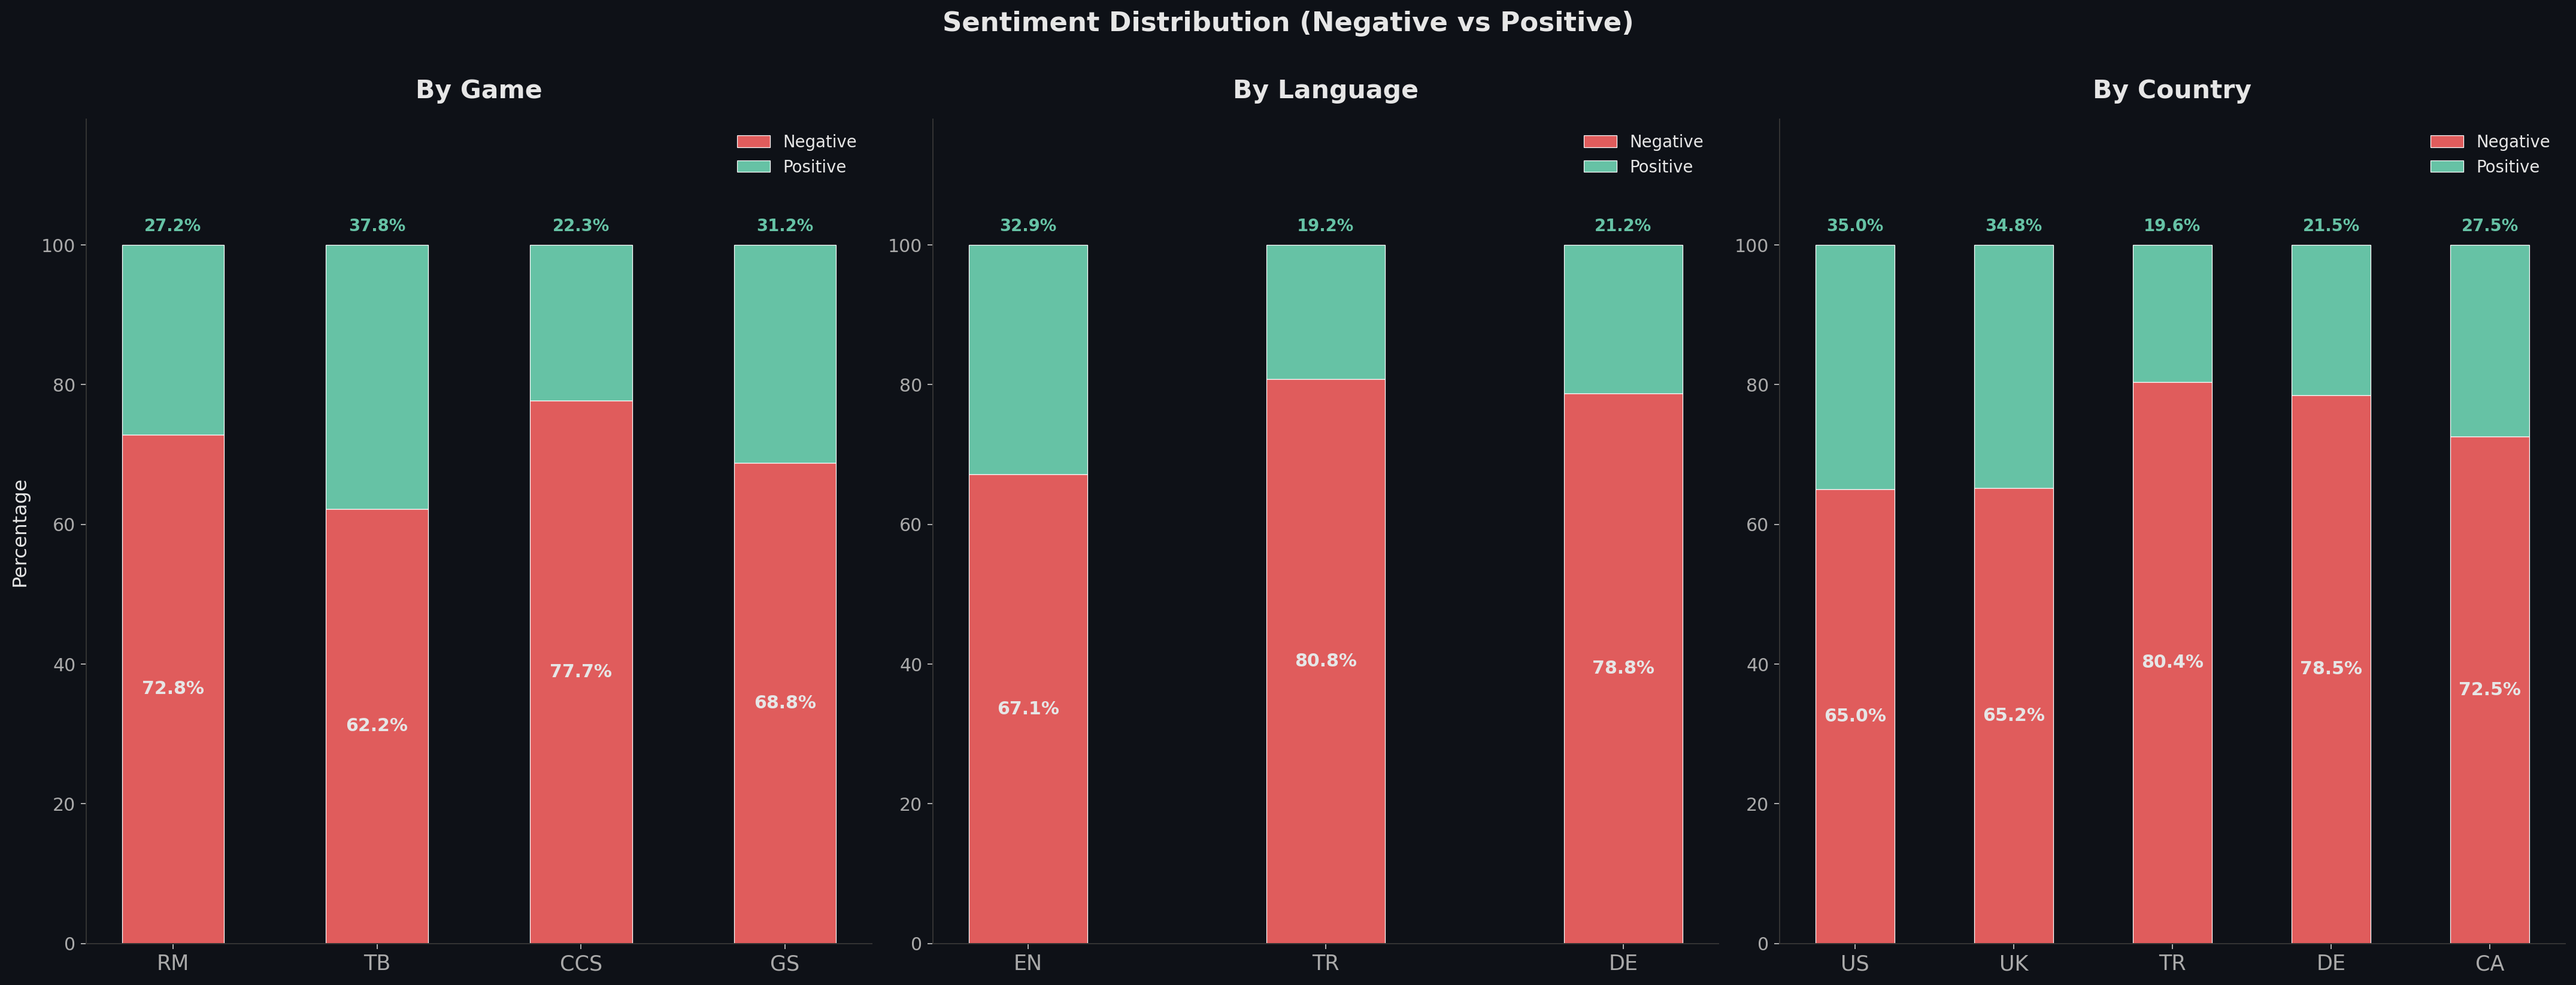


2A — Counts
  By game:
ml_sentiment      negative  positive
game                                
Royal Match           1646       614
Toon Blast             676       411
Candy Crush Saga      1566       450
Gardenscapes          1288       585

  By language:
ml_sentiment  negative  positive
lang                            
EN                3185      1559
TR                1115       265
DE                 876       236

  By country:
ml_sentiment    negative  positive
country                           
United States       1147       618
United Kingdom      1075       575
Turkey              1131       276
Germany              953       261
Canada               853       323


In [6]:
# =============================================================================
# STEP 02A — Sentiment Distribution (by Game, Language & Country)
# =============================================================================
section("2A — Sentiment Distribution")

sent_by_game = (
    df_reviews.groupby(["game", "ml_sentiment"])
    .size().reset_index(name="n")
)
sent_by_game["pct"] = (
    sent_by_game.groupby("game")["n"]
    .transform(lambda x: x / x.sum() * 100)
)

neg = sent_by_game[sent_by_game.ml_sentiment == "negative"].set_index("game").reindex(GAME_ORDER)
pos = sent_by_game[sent_by_game.ml_sentiment == "positive"].set_index("game").reindex(GAME_ORDER)

sent_by_lang = (
    df_reviews.groupby(["lang", "ml_sentiment"])
    .size().reset_index(name="n")
)
sent_by_lang["pct"] = (
    sent_by_lang.groupby("lang")["n"]
    .transform(lambda x: x / x.sum() * 100)
)
neg_l = sent_by_lang[sent_by_lang.ml_sentiment == "negative"].set_index("lang").reindex(LANGS)
pos_l = sent_by_lang[sent_by_lang.ml_sentiment == "positive"].set_index("lang").reindex(LANGS)

COUNTRY_ORDER = ["United States", "United Kingdom", "Turkey", "Germany", "Canada"]
COUNTRY_SHORT = {"United States": "US", "United Kingdom": "UK", "Turkey": "TR",
                 "Germany": "DE", "Canada": "CA"}
COUNTRY_PALETTE = {
    "United States":  "#1f4ed8",
    "United Kingdom": "#3b82f6",
    "Turkey":         "#FC8D62",
    "Germany":        "#7FA2E8",
    "Canada":         "#60a5fa",
}

sent_by_country = (
    df_reviews[df_reviews.country.isin(COUNTRY_ORDER)]
    .groupby(["country", "ml_sentiment"])
    .size().reset_index(name="n")
)
sent_by_country["pct"] = (
    sent_by_country.groupby("country")["n"]
    .transform(lambda x: x / x.sum() * 100)
)
neg_c = sent_by_country[sent_by_country.ml_sentiment == "negative"].set_index("country").reindex(COUNTRY_ORDER)
pos_c = sent_by_country[sent_by_country.ml_sentiment == "positive"].set_index("country").reindex(COUNTRY_ORDER)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 9))

# ── Helper for stacked bar + labels ──────────────────────────────────────────
def draw_stacked(ax, x_pos, neg_vals, pos_vals, labels, width=0.5):
    bars_neg = ax.bar(x_pos, neg_vals, color=SENTIMENT_COLORS["negative"],
                      edgecolor="white", linewidth=0.5, label="Negative", width=width)
    bars_pos = ax.bar(x_pos, pos_vals, bottom=neg_vals,
                      color=SENTIMENT_COLORS["positive"], edgecolor="white",
                      linewidth=0.5, label="Positive", width=width)
    for bar, val in zip(bars_neg, neg_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                f"{val:.1f}%", ha="center", va="center", fontsize=12, fontweight="bold")
    for bar, vn, vp in zip(bars_pos, neg_vals, pos_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, vn + vp + 1.5,
                f"{vp:.1f}%", ha="center", va="bottom", fontsize=11,
                fontweight="bold", color=SENTIMENT_COLORS["positive"])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_ylim(0, 118)
    ax.legend(loc="upper right", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

# ── Left: by game ────────────────────────────────────────────────────────────
GAME_SHORT = {"Royal Match": "RM", "Toon Blast": "TB", "Candy Crush Saga": "CCS", "Gardenscapes": "GS"}
draw_stacked(ax1, np.arange(len(GAME_ORDER)), neg["pct"].values, pos["pct"].values,
             [GAME_SHORT[g] for g in GAME_ORDER])
ax1.set_ylabel("Percentage", fontsize=13, labelpad=8)
ax1.set_title("By Game", fontsize=17, fontweight="bold", pad=14)

# ── Middle: by language ──────────────────────────────────────────────────────
draw_stacked(ax2, np.arange(len(LANGS)), neg_l["pct"].values, pos_l["pct"].values,
             LANGS, width=0.4)
ax2.set_ylabel("")
ax2.set_title("By Language", fontsize=17, fontweight="bold", pad=14)

# ── Right: by country ────────────────────────────────────────────────────────
draw_stacked(ax3, np.arange(len(COUNTRY_ORDER)), neg_c["pct"].values, pos_c["pct"].values,
             [COUNTRY_SHORT[c] for c in COUNTRY_ORDER])
ax3.set_ylabel("")
ax3.set_title("By Country", fontsize=17, fontweight="bold", pad=14)

plt.suptitle("Sentiment Distribution (Negative vs Positive)",
             fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print counts
section("2A — Counts")
print("  By game:")
print(sent_by_game.pivot(index="game", columns="ml_sentiment", values="n").reindex(GAME_ORDER).to_string())
print("\n  By language:")
print(sent_by_lang.pivot(index="lang", columns="ml_sentiment", values="n").reindex(LANGS).to_string())
print("\n  By country:")
print(sent_by_country.pivot(index="country", columns="ml_sentiment", values="n").reindex(COUNTRY_ORDER).to_string())


2B — Rating × Sentiment Heatmap


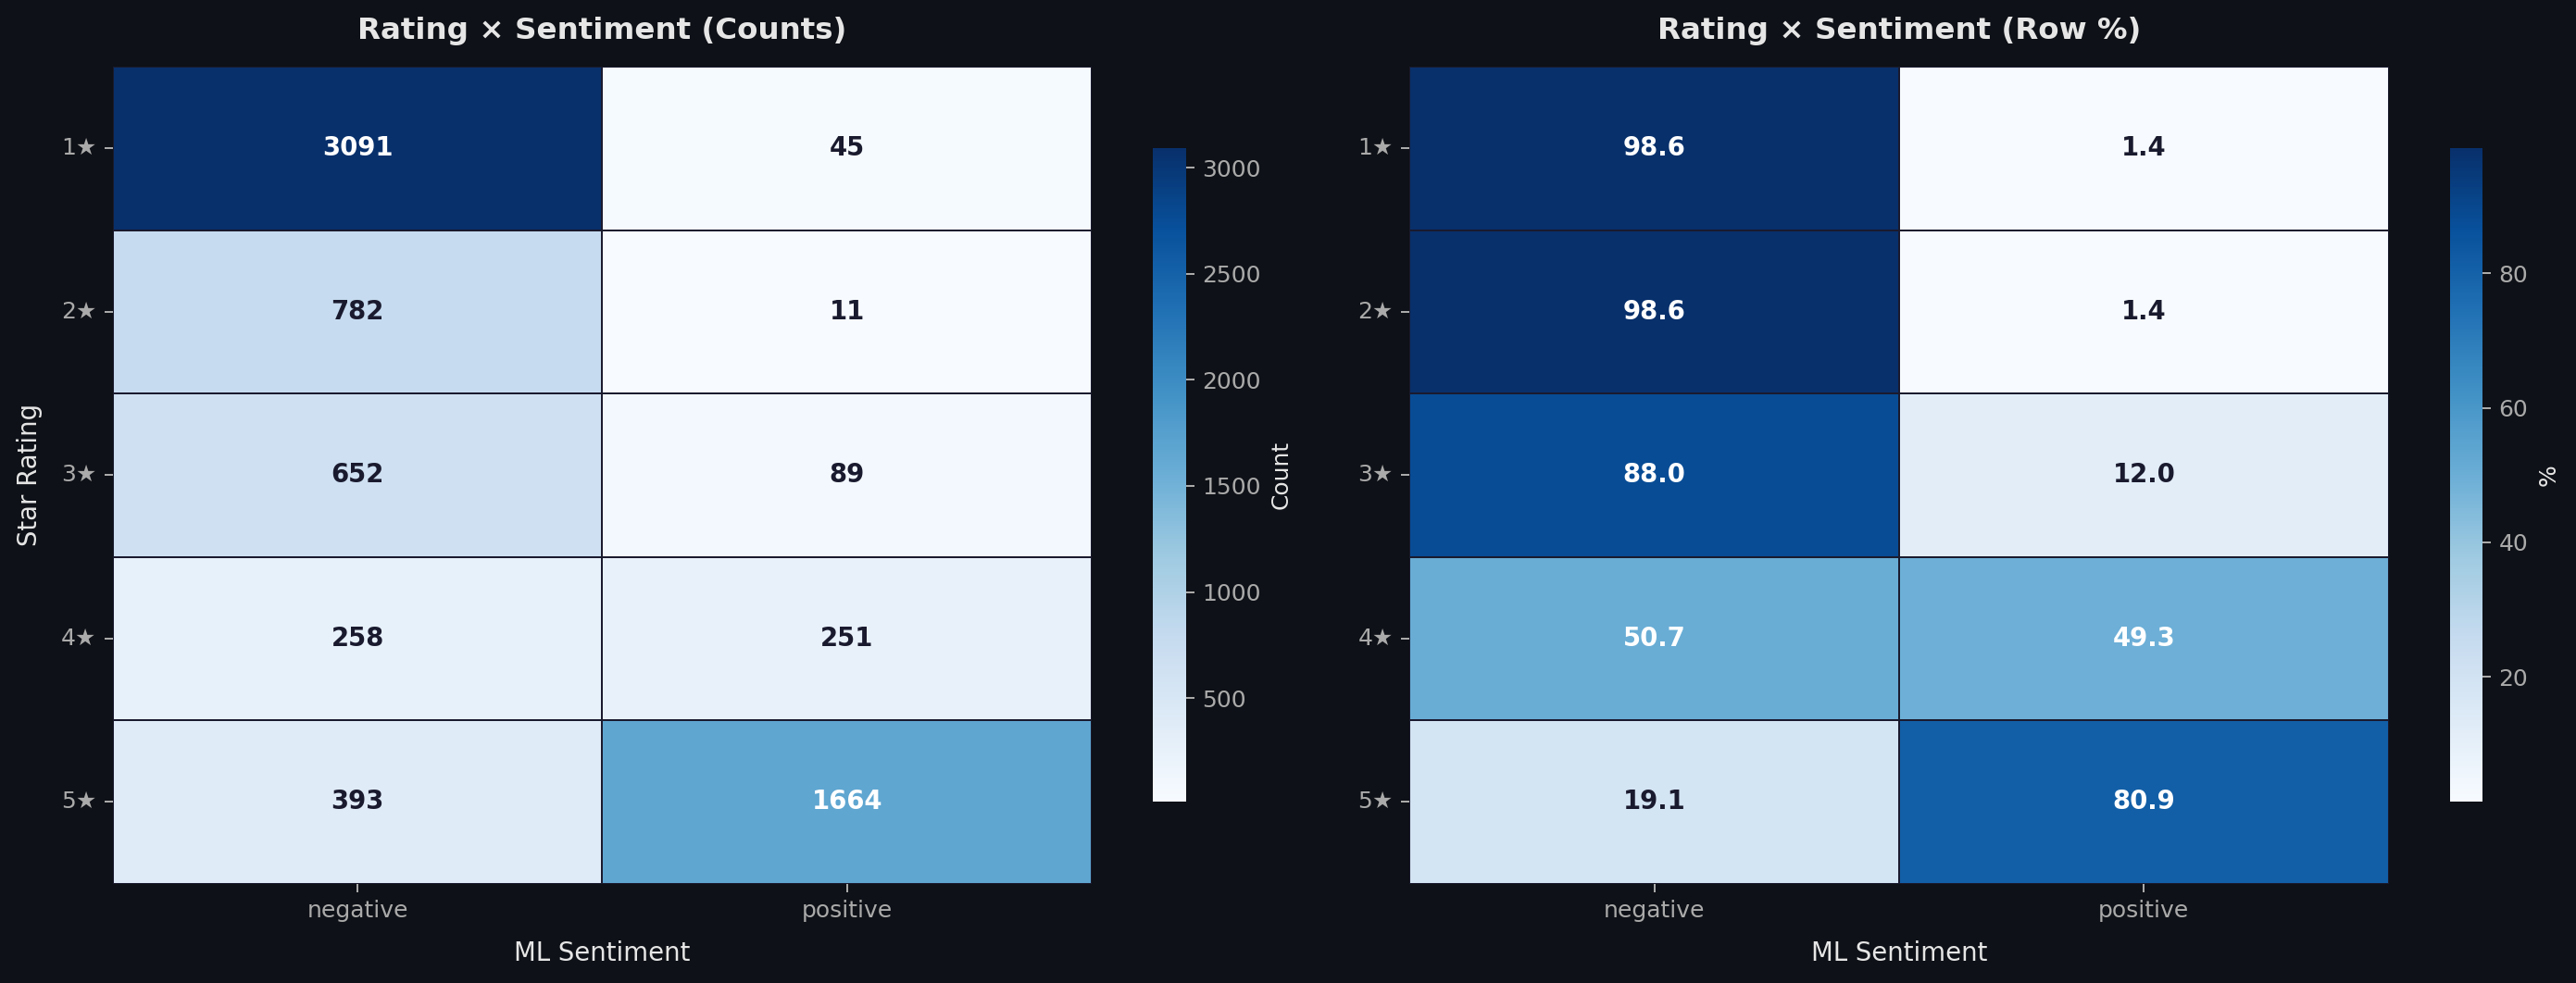


2B — Rating-Sentiment Divergence
  4★ reviews with negative sentiment: 258/509 (50.7%)
  5★ reviews with negative sentiment: 393/2057 (19.1%)
  1★ reviews with positive sentiment: 45/3136 (1.4%)
  2★ reviews with positive sentiment: 11/793 (1.4%)


In [7]:
# =============================================================================
# STEP 02B — Rating × Sentiment Cross-Tabulation
# =============================================================================
section("2B — Rating × Sentiment Heatmap")

# Cross-tab: rows = rating, columns = sentiment, values = count
ct = pd.crosstab(df_reviews["rating"], df_reviews["ml_sentiment"])
ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Annotation color: white on dark cells, dark on light cells
def annot_colors(data, threshold_pct=0.4):
    """Return color array: white for high values, dark for low."""
    normed = (data - data.min().min()) / (data.max().max() - data.min().min())
    return np.where(normed > threshold_pct, "white", "#1a1a2e")

# ── Left: absolute counts ────────────────────────────────────────────────────
sns.heatmap(
    ct, annot=True, fmt="d", cmap="Blues",
    linewidths=0.8, linecolor="#1a1a2e",
    cbar_kws={"label": "Count", "shrink": 0.8},
    annot_kws={"fontweight": "bold", "fontsize": 11},
    ax=ax1,
)
# Fix annotation colors
colors = annot_colors(ct.values)
for i, text in enumerate(ax1.texts):
    row, col = divmod(i, ct.shape[1])
    text.set_color(colors[row, col])

ax1.set_title("Rating × Sentiment (Counts)", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("ML Sentiment", fontsize=11, labelpad=8)
ax1.set_ylabel("Star Rating", fontsize=11, labelpad=8)
ax1.set_yticklabels([f"{r}★" for r in range(1, 6)], rotation=0, fontsize=10)

# ── Right: row-normalized percentages ────────────────────────────────────────
sns.heatmap(
    ct_pct, annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.8, linecolor="#1a1a2e",
    cbar_kws={"label": "%", "shrink": 0.8},
    annot_kws={"fontweight": "bold", "fontsize": 11},
    ax=ax2,
)
colors_pct = annot_colors(ct_pct.values)
for i, text in enumerate(ax2.texts):
    row, col = divmod(i, ct_pct.shape[1])
    text.set_color(colors_pct[row, col])

ax2.set_title("Rating × Sentiment (Row %)", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("ML Sentiment", fontsize=11, labelpad=8)
ax2.set_ylabel("")
ax2.set_yticklabels([f"{r}★" for r in range(1, 6)], rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Print the divergence cases
section("2B — Rating-Sentiment Divergence")
for r in [4, 5]:
    sub = df_reviews[df_reviews.rating == r]
    n_neg = (sub.ml_sentiment == "negative").sum()
    total = len(sub)
    print(f"  {r}★ reviews with negative sentiment: {n_neg}/{total} ({n_neg/total*100:.1f}%)")

for r in [1, 2]:
    sub = df_reviews[df_reviews.rating == r]
    n_pos = (sub.ml_sentiment == "positive").sum()
    total = len(sub)
    print(f"  {r}★ reviews with positive sentiment: {n_pos}/{total} ({n_pos/total*100:.1f}%)")


2C — Hidden Dissatisfaction: 4-5★ with Negative Sentiment


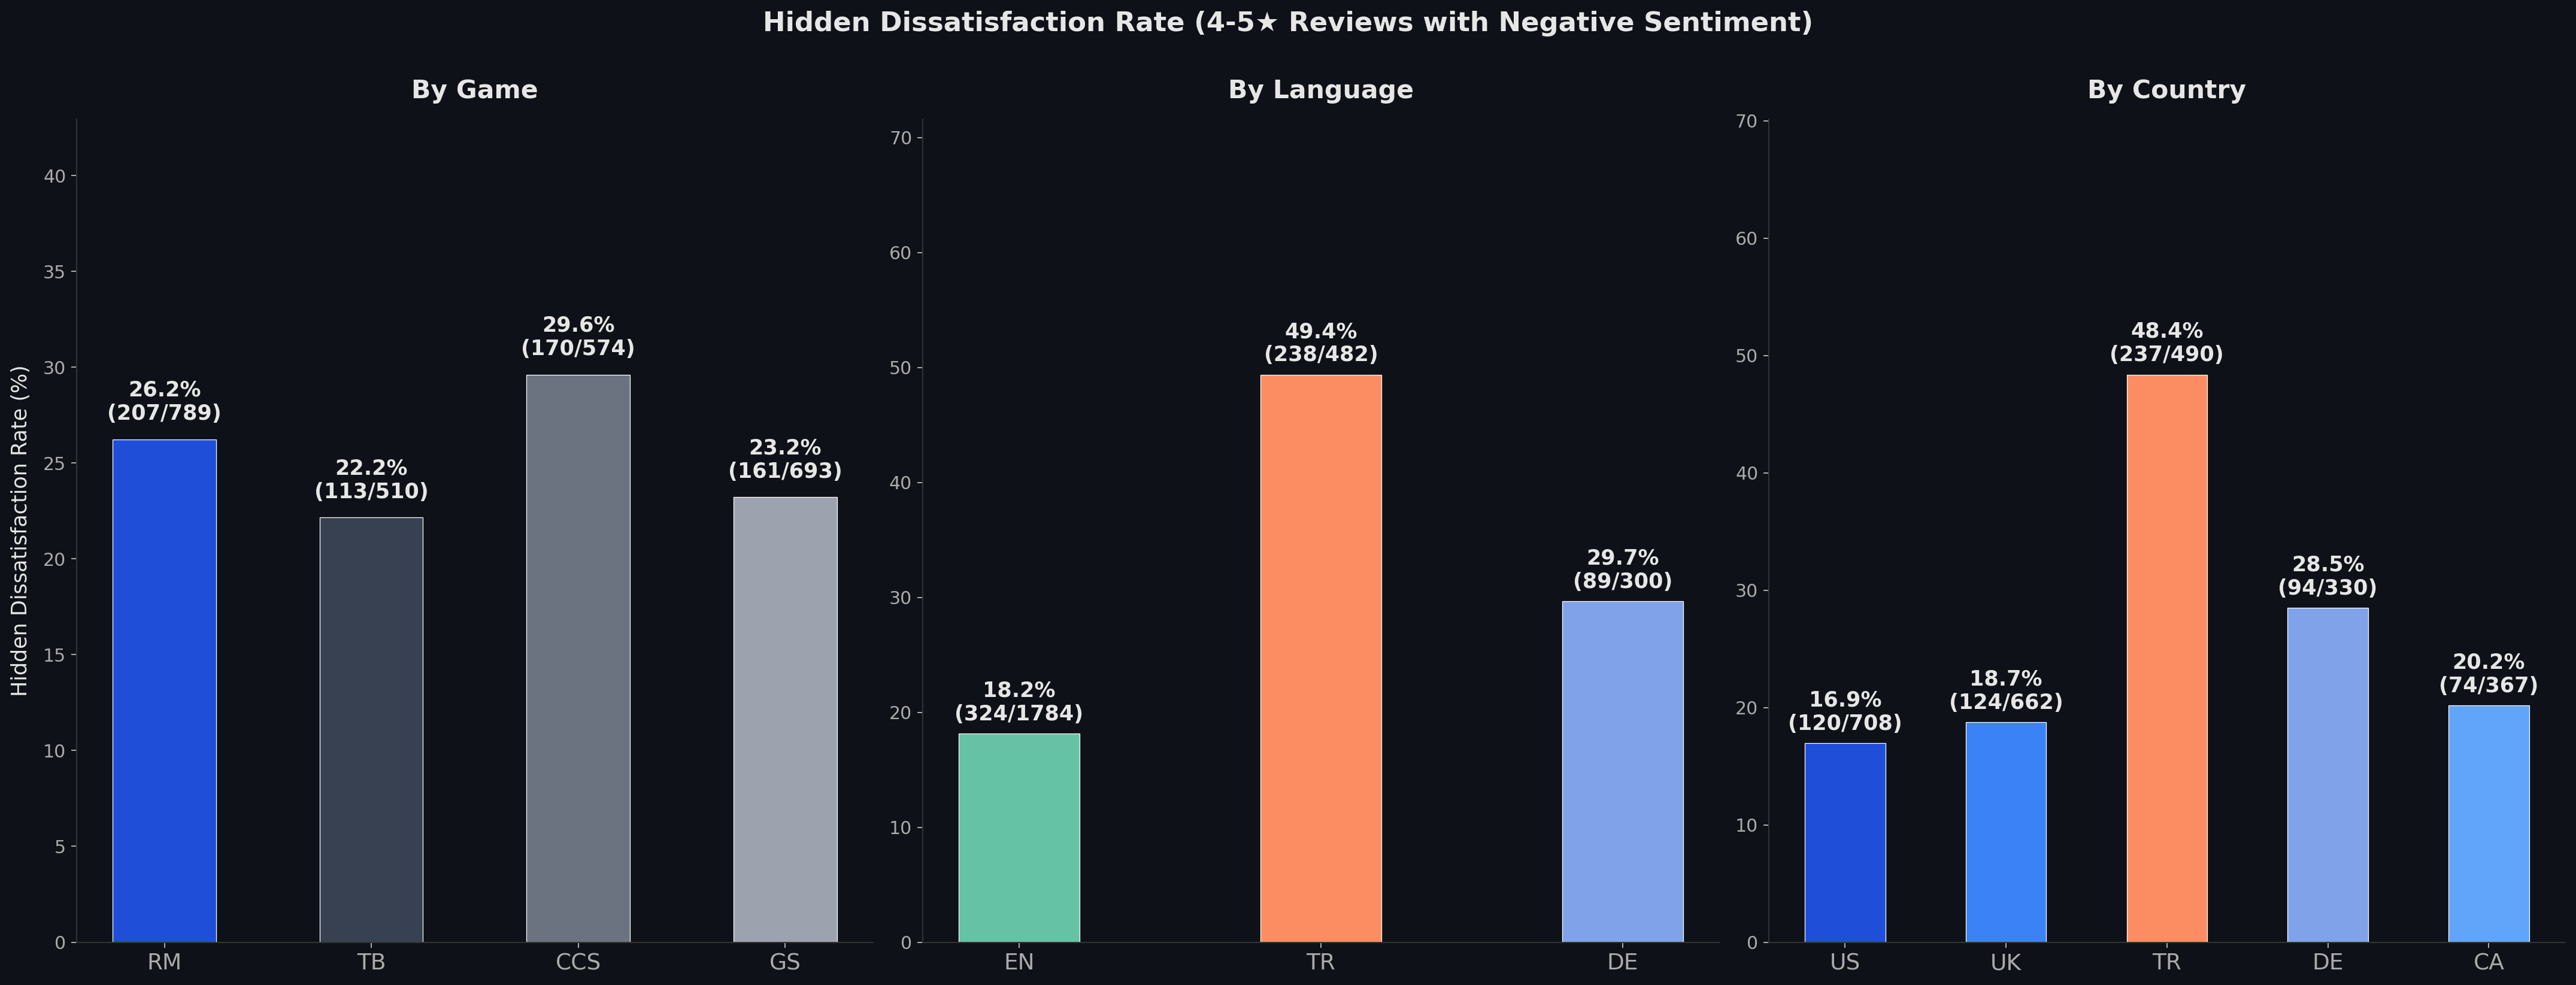

In [8]:
# =============================================================================
# STEP 02C — Hidden Dissatisfaction (High Rating + Negative Sentiment)
# =============================================================================
section("2C — Hidden Dissatisfaction: 4-5★ with Negative Sentiment")

df_high = df_reviews[df_reviews.rating >= 4].copy()
df_high["hidden_dissatisfied"] = df_high["ml_sentiment"] == "negative"

# ── By game ──────────────────────────────────────────────────────────────────
hd_game = (
    df_high.groupby("game")
    .agg(total=("review_id", "count"),
         n_hidden=("hidden_dissatisfied", "sum"))
    .assign(pct=lambda d: d.n_hidden / d.total * 100)
    .reindex(GAME_ORDER)
)

# ── By language ──────────────────────────────────────────────────────────────
hd_lang = (
    df_high.groupby("lang")
    .agg(total=("review_id", "count"),
         n_hidden=("hidden_dissatisfied", "sum"))
    .assign(pct=lambda d: d.n_hidden / d.total * 100)
    .reindex(LANGS)
)

# ── By country ───────────────────────────────────────────────────────────────
COUNTRY_ORDER = ["United States", "United Kingdom", "Turkey", "Germany", "Canada"]
COUNTRY_SHORT = {"United States": "US", "United Kingdom": "UK", "Turkey": "TR",
                 "Germany": "DE", "Canada": "CA"}
COUNTRY_PALETTE = {
    "United States":  "#1f4ed8",
    "United Kingdom": "#3b82f6",
    "Turkey":         "#FC8D62",
    "Germany":        "#7FA2E8",
    "Canada":         "#60a5fa",
}

hd_country = (
    df_high[df_high.country.isin(COUNTRY_ORDER)]
    .groupby("country")
    .agg(total=("review_id", "count"),
         n_hidden=("hidden_dissatisfied", "sum"))
    .assign(pct=lambda d: d.n_hidden / d.total * 100)
    .reindex(COUNTRY_ORDER)
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 9))

# ── Left: by game ───────────────────────────────────────────────────────────
x = np.arange(len(GAME_ORDER))
colors_game = [HIGHLIGHT_COLOR if g == HIGHLIGHT_GAME else COMPETITOR_PALETTE.get(g, "#6b7280") for g in GAME_ORDER]
GAME_SHORT = {"Royal Match": "RM", "Toon Blast": "TB", "Candy Crush Saga": "CCS", "Gardenscapes": "GS"}

bars = ax1.bar(x, hd_game["pct"], color=colors_game, edgecolor="white", linewidth=0.5, width=0.5)
for bar, pct, n, total in zip(bars, hd_game["pct"], hd_game["n_hidden"], hd_game["total"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{pct:.1f}%\n({n}/{total})", ha="center", va="bottom", fontsize=14, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels([GAME_SHORT[g] for g in GAME_ORDER], fontsize=15)
ax1.set_ylabel("Hidden Dissatisfaction Rate (%)", fontsize=14, labelpad=8)
ax1.set_title("By Game", fontsize=17, fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_ylim(0, hd_game["pct"].max() * 1.45)
ax1.tick_params(axis="y", labelsize=12)

# ── Middle: by language ──────────────────────────────────────────────────────
xl = np.arange(len(LANGS))
colors_lang = [LANG_PALETTE[l] for l in LANGS]

bars_l = ax2.bar(xl, hd_lang["pct"], color=colors_lang, edgecolor="white", linewidth=0.5, width=0.4)
for bar, pct, n, total in zip(bars_l, hd_lang["pct"], hd_lang["n_hidden"], hd_lang["total"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{pct:.1f}%\n({n}/{total})", ha="center", va="bottom", fontsize=14, fontweight="bold")

ax2.set_xticks(xl)
ax2.set_xticklabels(LANGS, fontsize=15)
ax2.set_ylabel("")
ax2.set_title("By Language", fontsize=17, fontweight="bold", pad=14)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_ylim(0, hd_lang["pct"].max() * 1.45)
ax2.tick_params(axis="y", labelsize=12)

# ── Right: by country ───────────────────────────────────────────────────────
xc = np.arange(len(COUNTRY_ORDER))
colors_c = [COUNTRY_PALETTE[c] for c in COUNTRY_ORDER]

bars_c = ax3.bar(xc, hd_country["pct"], color=colors_c, edgecolor="white", linewidth=0.5, width=0.5)
for bar, pct, n, total in zip(bars_c, hd_country["pct"], hd_country["n_hidden"], hd_country["total"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
             f"{pct:.1f}%\n({n}/{total})", ha="center", va="bottom", fontsize=14, fontweight="bold")

ax3.set_xticks(xc)
ax3.set_xticklabels([COUNTRY_SHORT[c] for c in COUNTRY_ORDER], fontsize=15)
ax3.set_ylabel("")
ax3.set_title("By Country", fontsize=17, fontweight="bold", pad=14)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.set_ylim(0, hd_country["pct"].max() * 1.45)
ax3.tick_params(axis="y", labelsize=12)

plt.suptitle("Hidden Dissatisfaction Rate (4-5★ Reviews with Negative Sentiment)",
             fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# STEP 02C+ — Hidden Dissatisfaction: Example Reviews
# =============================================================================
section("2C — Example Reviews: High Rating + Negative Sentiment")

hd_examples = df_reviews[
    (df_reviews.rating >= 4) &
    (df_reviews.ml_sentiment == "negative") &
    (df_reviews.char_count > 50)
].copy()

print("  5★ reviews with negative sentiment:\n")
for _, r in hd_examples[hd_examples.rating == 5].sample(4, random_state=42).iterrows():
    print(f"  [{r.game} | {r.lang} | {r.rating}★ | conf={r.ml_confidence:.3f}]")
    print(f"  {r.review[:250]}")
    print()

print("  4★ reviews with negative sentiment:\n")
for _, r in hd_examples[hd_examples.rating == 4].sample(4, random_state=42).iterrows():
    print(f"  [{r.game} | {r.lang} | {r.rating}★ | conf={r.ml_confidence:.3f}]")
    print(f"  {r.review[:250]}")
    print()


2C — Example Reviews: High Rating + Negative Sentiment
  5★ reviews with negative sentiment:

  [Candy Crush Saga | EN | 5★ | conf=1.000]
  Good game but my problem is when the game just hang out of the random after an ad especially when you are about to clear a  good reward I honestly feel this game hanging is on purpose and programmed I’m on level 6k plus and it’s annoys me everytime

  [Royal Match | EN | 5★ | conf=1.000]
  I only did 5 starts because you would see this truthfully Nothing like the game all you do is sit around. Endless adds. Never getting agian. Don’t get. Ruined my childhood memories of this game.

  [Candy Crush Saga | TR | 5★ | conf=0.987]
  Reklamlar çok uzun ve uygunsuz sitelerin reklamları sonuçta çocuklarda oynuyor bu oyunu dimi

  [Royal Match | TR | 5★ | conf=0.961]
  Çok severek heyecanla oynuyorum ama her geçen gün zorlaşıyor silmeyi bile düşünüyorum zorlanınca bu kadar zorlaştırmak zorundamısınız tşk

  4★ reviews with negative sentiment:

  [Toon Blast

> **Key observation:** These examples illustrate why star ratings alone are misleading. A Royal Match user gives 5★ but writes *"Nothing like the game, all you do is sit around. Endless ads. Never getting again."* — a clear churn signal buried under a perfect rating. The Turkish reviews show the same pattern: *"Çok severek oynuyorum ama... silmeyi bile düşünüyorum"* (I love playing but I'm even thinking of deleting it) — positive framing with negative intent. The 4★ examples are even more actionable: specific monetization complaints (coin reduction, difficulty manipulation, pay-to-progress) with high model confidence (0.997–1.000). These are users who still engage but are approaching a tipping point — exactly the segment a product team should prioritize.


2D — Weekly Negative Sentiment Rate: RM vs Competitors


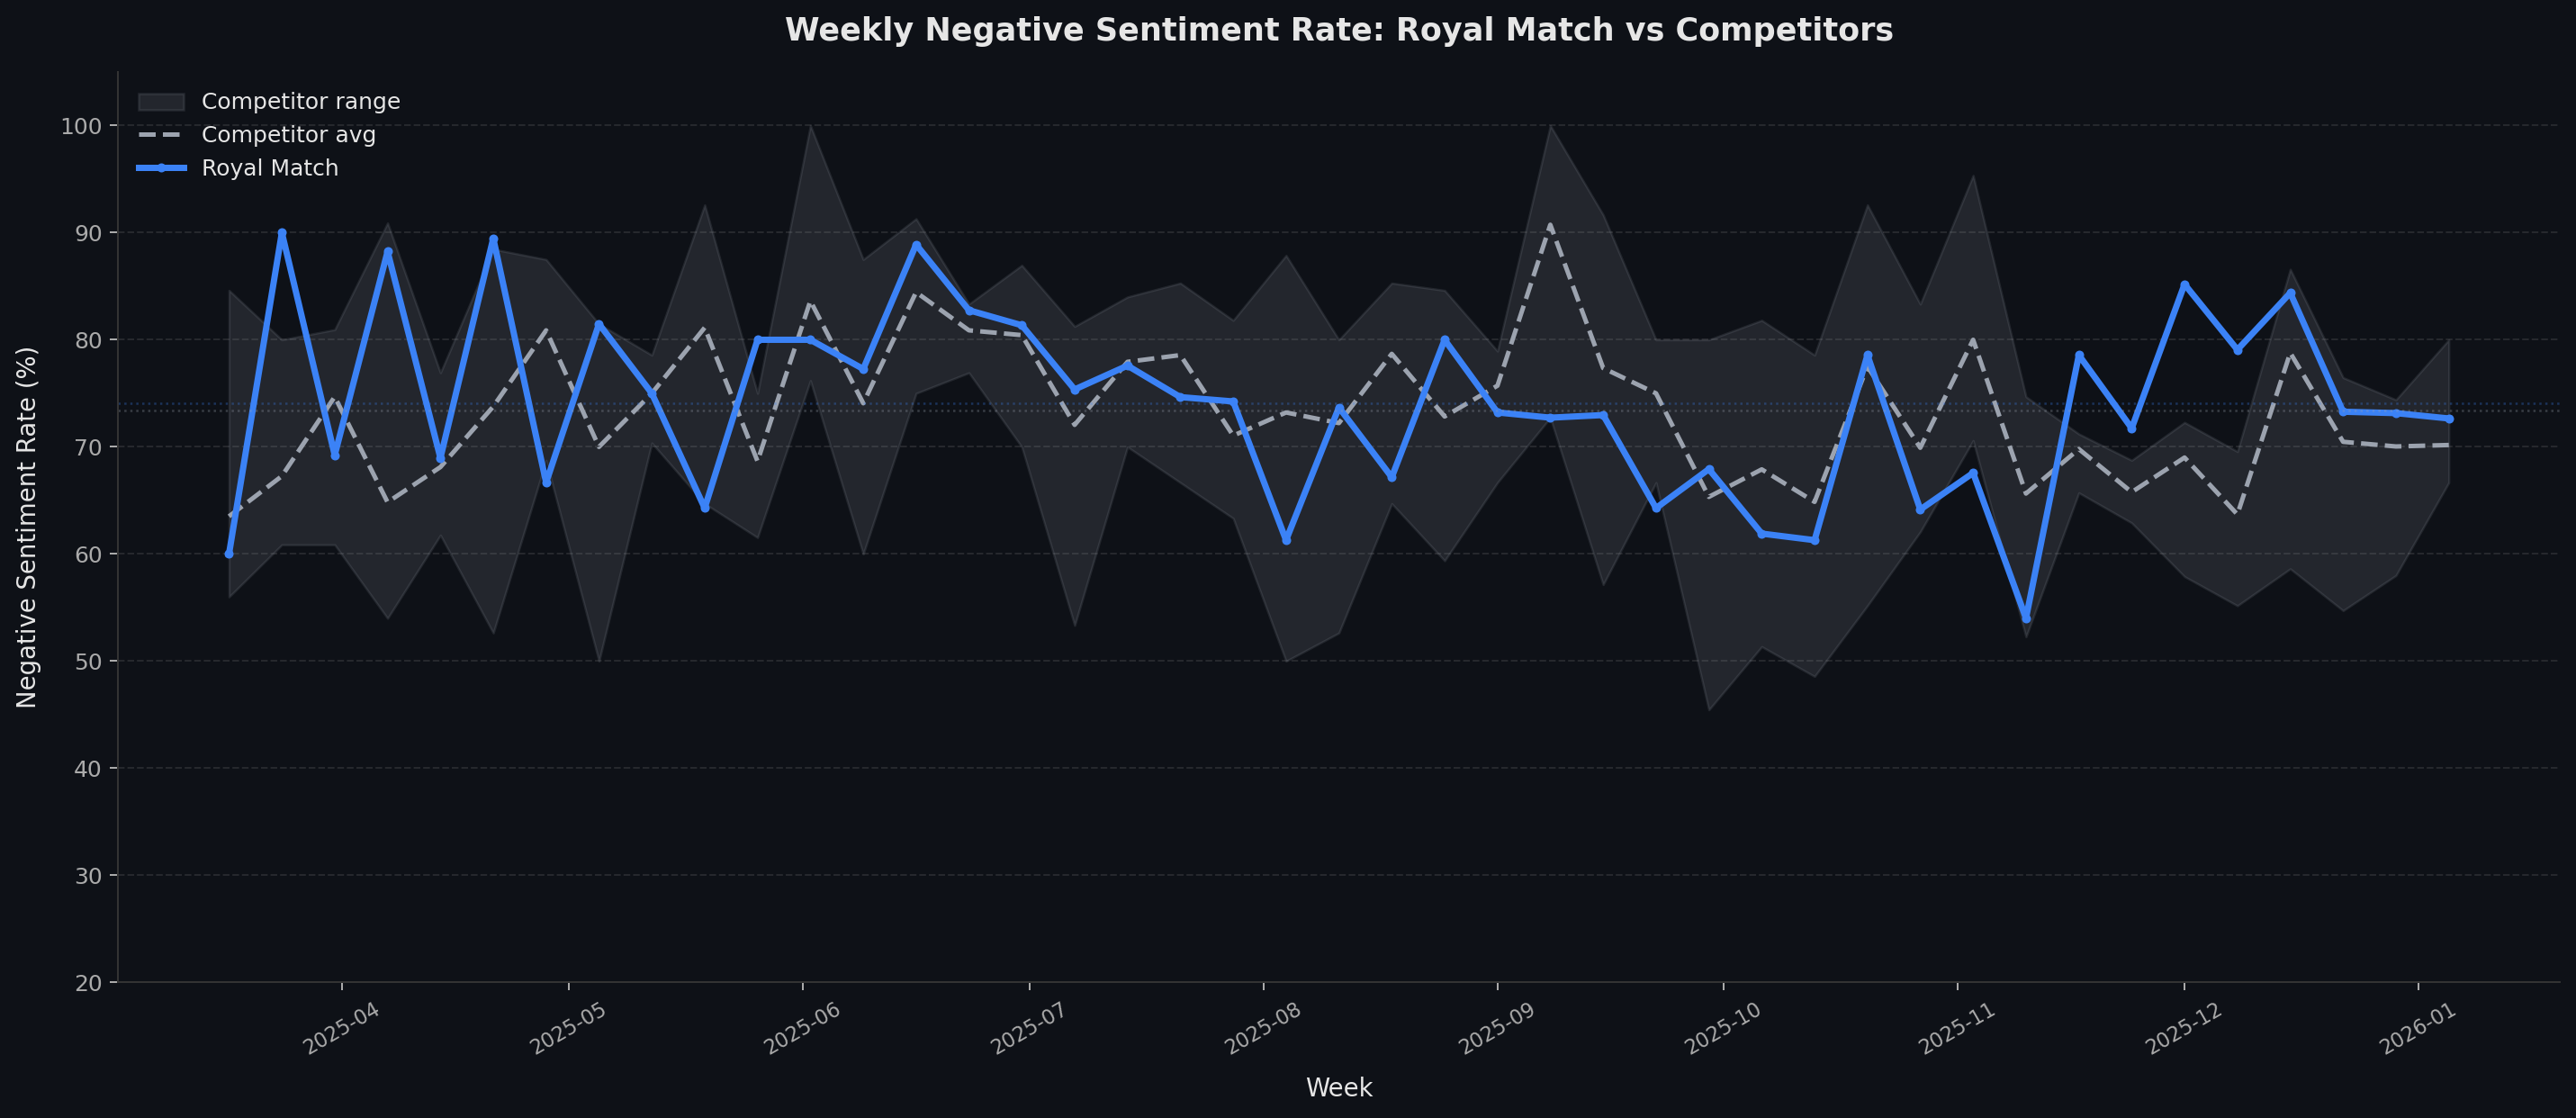


2D — Summary
  Royal Match     : avg neg_rate = 74.1%, range = 54.0% – 90.0%
  Competitor avg  : avg neg_rate = 73.4%, range = 63.5% – 90.7%
  Gap (RM - Comp) : +0.7 pp


In [10]:
# =============================================================================
# STEP 02D — Sentiment Trend: Royal Match vs Competitor Average
# =============================================================================
section("2D — Weekly Negative Sentiment Rate: RM vs Competitors")

df_reviews["week"] = df_reviews["date"].dt.to_period("W").apply(lambda p: p.start_time)

weekly = (
    df_reviews.groupby(["week", "game"])
    .agg(n_reviews=("review_id", "count"),
         n_neg=("ml_sentiment", lambda x: (x == "negative").sum()))
    .reset_index()
)
weekly["neg_rate"] = weekly["n_neg"] / weekly["n_reviews"]

# Filter weeks with at least 5 reviews per game for stability
weekly = weekly[weekly.n_reviews >= 5]

# Royal Match
rm = weekly[weekly.game == "Royal Match"].sort_values("week").set_index("week")

# Competitor average (weighted by review count per week)
comp = weekly[weekly.game != "Royal Match"].groupby("week").agg(
    n_reviews=("n_reviews", "sum"),
    n_neg=("n_neg", "sum"),
).assign(neg_rate=lambda d: d.n_neg / d.n_reviews)

# Competitor min/max band per week
comp_band = weekly[weekly.game != "Royal Match"].groupby("week")["neg_rate"].agg(["min", "max"])
comp = comp.join(comp_band)

# Align on common weeks
common_weeks = rm.index.intersection(comp.index).sort_values()
rm = rm.loc[common_weeks]
comp = comp.loc[common_weeks]

fig, ax = plt.subplots(figsize=(16, 7))

# Competitor band (min-max range across 3 competitors)
ax.fill_between(common_weeks, comp["min"] * 100, comp["max"] * 100,
                alpha=0.15, color="#9ca3af", label="Competitor range")

# Competitor weighted average
ax.plot(common_weeks, comp["neg_rate"] * 100,
        color="#9ca3af", linewidth=2, linestyle="--", label="Competitor avg")

# Royal Match
ax.plot(common_weeks, rm["neg_rate"] * 100,
        color="#3b82f6", linewidth=2.8, label="Royal Match", marker="o", markersize=3)

# Average lines (subtle)
rm_avg = rm["neg_rate"].mean() * 100
comp_avg = comp["neg_rate"].mean() * 100
ax.axhline(y=rm_avg, color="#3b82f6", linestyle=":", alpha=0.3, linewidth=1)
ax.axhline(y=comp_avg, color="#9ca3af", linestyle=":", alpha=0.3, linewidth=1)

ax.set_xlabel("Week", fontsize=11, labelpad=8)
ax.set_ylabel("Negative Sentiment Rate (%)", fontsize=11, labelpad=8)
ax.set_title("Weekly Negative Sentiment Rate: Royal Match vs Competitors",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(loc="upper left", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.15)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.set_ylim(20, 105)

plt.tight_layout()
plt.show()

# Print summary below chart
section("2D — Summary")
print(f"  Royal Match     : avg neg_rate = {rm_avg:.1f}%, range = {rm['neg_rate'].min()*100:.1f}% – {rm['neg_rate'].max()*100:.1f}%")
print(f"  Competitor avg  : avg neg_rate = {comp_avg:.1f}%, range = {comp['neg_rate'].min()*100:.1f}% – {comp['neg_rate'].max()*100:.1f}%")
print(f"  Gap (RM - Comp) : {rm_avg - comp_avg:+.1f} pp")

### Step 02 — Summary

**Rating is an unreliable satisfaction proxy.** 50.7% of 4★ and 19.1% of 5★ reviews carry negative sentiment — star ratings systematically overestimate user satisfaction. The reverse is negligible: only 1.4% of 1-2★ reviews are positive. This asymmetry means product teams relying solely on average rating miss a substantial pool of dissatisfied users.

**Hidden dissatisfaction is market-dependent.** TR stands out at 49.4% (language) / 48.4% (country) — nearly half of all high-rating Turkish reviews express negative sentiment. EN markets (US 16.9%, UK 18.7%) are far lower. This suggests TR users may use high ratings as a general endorsement while using review text to voice specific complaints — a cultural pattern that pure rating analysis would completely miss.

**Game-level patterns are moderate.** CCS leads hidden dissatisfaction at 29.6%, RM at 26.2%, TB lowest at 22.2%. Differences are smaller than language/country effects, suggesting market composition drives more variation than product differences.

**Sentiment trends are stable.** RM and competitor average track closely over time (gap: +0.7pp) with no sustained divergence. Weekly volatility exists (RM range: 54–90%) but no structural shift is visible — specific version-level effects will be tested in H1.

**Key implication:** Any review analytics pipeline that uses star ratings as a sentiment proxy will significantly undercount negative feedback, especially in TR/DE markets. ML-based sentiment classification is essential for accurate product intelligence.

## Step 03 — Topic × Sentiment Matrix

This step shifts from review-level to **segment-level (ABSA)** analysis. Each segment has a BERTopic-assigned topic and a fine-tuned sentiment label — combining these reveals which product areas drive the most negativity and where satisfaction concentrates.

**Sub-steps:**
- **3A** — Topic × Sentiment heatmap (negative rate per topic)
- **3B** — Most complained vs most praised topics (top subtopics)
- **3C** — Topic distribution comparison across games — do different games have different pain points?
- **3D** — Topic distribution by country

The primary table here is `df_segments` (14,107 segments). UNASSIGNED segments are included for completeness but flagged — they represent segments BERTopic couldn't classify.


3A — Topic Negative Rate & Impact
  Total unique reviews with segments: 5,901

                      n_segments  n_reviews  n_neg_segments  neg_reviews  neg_rate  penetration  impact
main_topic                                                                                             
MONETIZATION_ECONOMY        3935       2217            3649         2122     0.927        0.376   0.360
ADS_EXPERIENCE              2483       1848            1950         1487     0.785        0.313   0.252
GAMEPLAY                    2954       1933            2358         1607     0.798        0.328   0.272
TECHNICAL_SUPPORT           1625       1168            1514         1097     0.932        0.198   0.186
COMMUNITY_SOCIAL             289        200             196          136     0.678        0.034   0.023


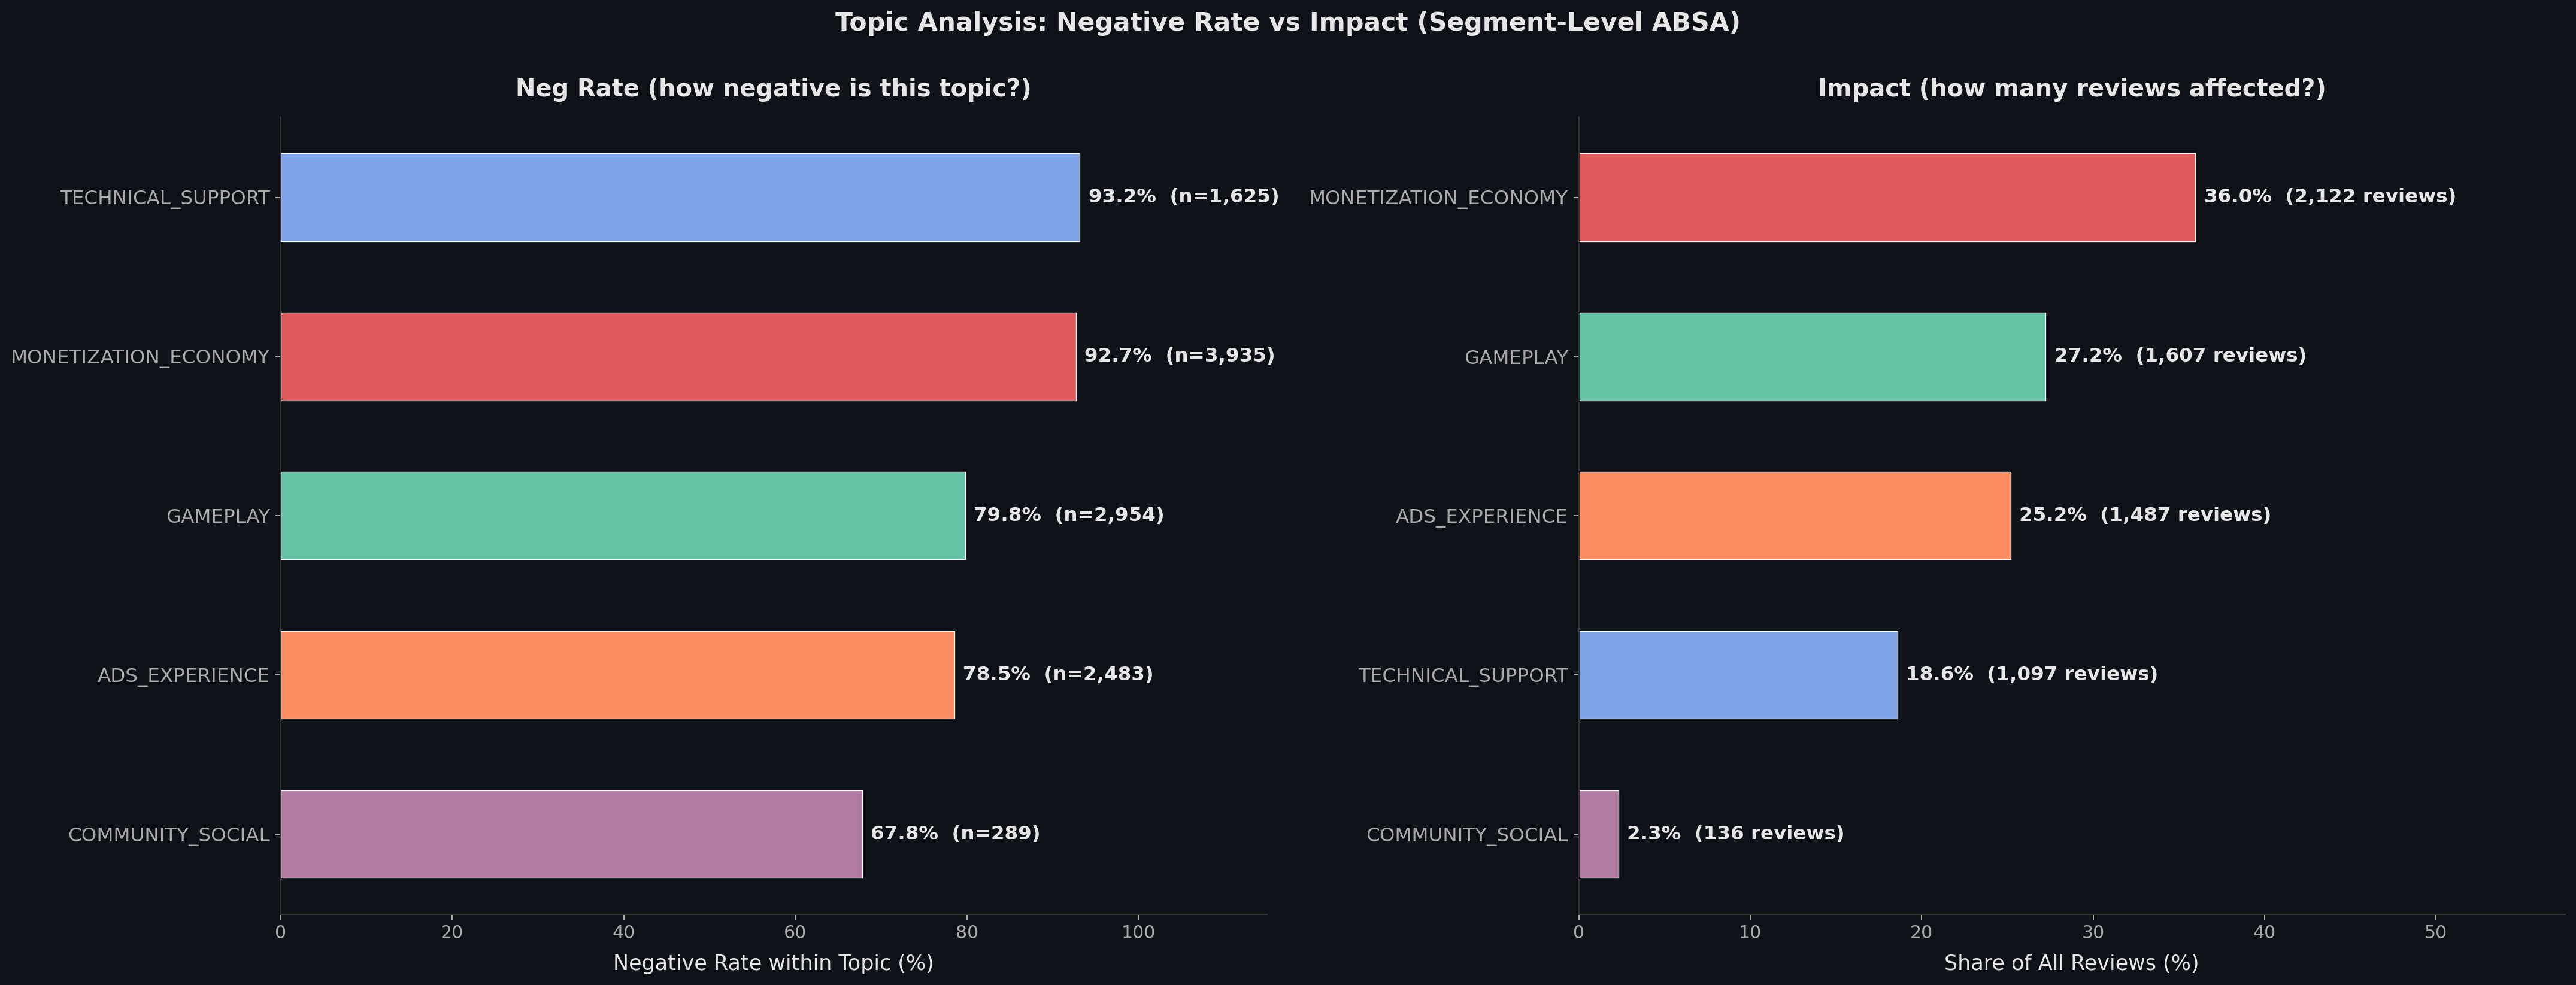

In [11]:
# =============================================================================
# STEP 03A — Topic × Sentiment: Negative Rate + Impact (Main Topics)
# =============================================================================
section("3A — Topic Negative Rate & Impact")

# Total unique reviews in df_segments
total_reviews = df_segments.review_id.nunique()
print(f"  Total unique reviews with segments: {total_reviews:,}\n")

# Exclude UNASSIGNED/OTHER
df_seg_clean = df_segments[~df_segments.main_topic.isin(["UNASSIGNED", "OTHER"])].copy()
TOPIC_ORDER_CLEAN = [t for t in TOPIC_ORDER if t not in ["UNASSIGNED", "OTHER"]]

# Per main_topic: unique reviews, negative segments, penetration, neg_rate, impact
topic_stats = []
for topic in TOPIC_ORDER_CLEAN:
    sub = df_seg_clean[df_seg_clean.main_topic == topic]
    n_segments = len(sub)
    n_reviews = sub.review_id.nunique()
    n_neg = (sub.seg_sentiment == "negative").sum()
    neg_rate = n_neg / n_segments if n_segments > 0 else 0
    penetration = n_reviews / total_reviews
    neg_reviews = sub[sub.seg_sentiment == "negative"].review_id.nunique()
    impact = neg_reviews / total_reviews
    topic_stats.append({
        "main_topic": topic, "n_segments": n_segments, "n_reviews": n_reviews,
        "n_neg_segments": n_neg, "neg_reviews": neg_reviews,
        "neg_rate": neg_rate, "penetration": penetration, "impact": impact,
    })

df_topic = pd.DataFrame(topic_stats).set_index("main_topic")
print(df_topic.round(3).to_string())

# ── Chart: dual view ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9))

df_plot = df_topic.sort_values("neg_rate", ascending=True)

# Left: Neg rate (within topic)
colors = [TOPIC_PALETTE[t] for t in df_plot.index]
bars1 = ax1.barh(df_plot.index, df_plot["neg_rate"] * 100,
                 color=colors, edgecolor="white", linewidth=0.5, height=0.55)
for bar, val, n in zip(bars1, df_plot["neg_rate"], df_plot["n_segments"]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{val*100:.1f}%  (n={n:,})", va="center", fontsize=13, fontweight="bold")

ax1.set_xlim(0, 115)
ax1.set_xlabel("Negative Rate within Topic (%)", fontsize=14, labelpad=8)
ax1.set_title("Neg Rate (how negative is this topic?)", fontsize=16, fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="y", labelsize=13)
ax1.tick_params(axis="x", labelsize=12)

# Right: Impact (share of all reviews with negative segment in this topic)
df_plot2 = df_topic.sort_values("impact", ascending=True)
colors2 = [TOPIC_PALETTE[t] for t in df_plot2.index]
bars2 = ax2.barh(df_plot2.index, df_plot2["impact"] * 100,
                 color=colors2, edgecolor="white", linewidth=0.5, height=0.55)
for bar, val, nr in zip(bars2, df_plot2["impact"], df_plot2["neg_reviews"]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val*100:.1f}%  ({nr:,} reviews)", va="center", fontsize=13, fontweight="bold")

ax2.set_xlim(0, df_topic["impact"].max() * 100 * 1.6)
ax2.set_xlabel("Share of All Reviews (%)", fontsize=14, labelpad=8)
ax2.set_title("Impact (how many reviews affected?)", fontsize=16, fontweight="bold", pad=14)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", labelsize=13)
ax2.tick_params(axis="x", labelsize=12)

plt.suptitle("Topic Analysis: Negative Rate vs Impact (Segment-Level ABSA)",
             fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


3B — Subtopic Negative Rate & Impact (Top 12)
                                    main_topic  n_segments  n_reviews  neg_rate  neg_reviews  impact
subtopic                                                                                            
MONETIZATION_P2W_REFUNDS  MONETIZATION_ECONOMY        2777       1738     0.936         1667   0.282
DIFFICULTY_BALANCE                    GAMEPLAY        1958       1384     0.884         1248   0.211
ADS_SCAM_DECEPTION              ADS_EXPERIENCE        1539       1188     0.865         1075   0.182
BUGS_STABILITY               TECHNICAL_SUPPORT        1028        803     0.968          786   0.133
REWARDS_POWERUPS          MONETIZATION_ECONOMY        1035        757     0.918          715   0.121
ADS_INTRUSION                   ADS_EXPERIENCE         606        467     0.962          456   0.077
GAME_CONTENT_MECHANICS                GAMEPLAY         874        684     0.625          433   0.073
UI_UX                        TECHNICAL_SUPPO

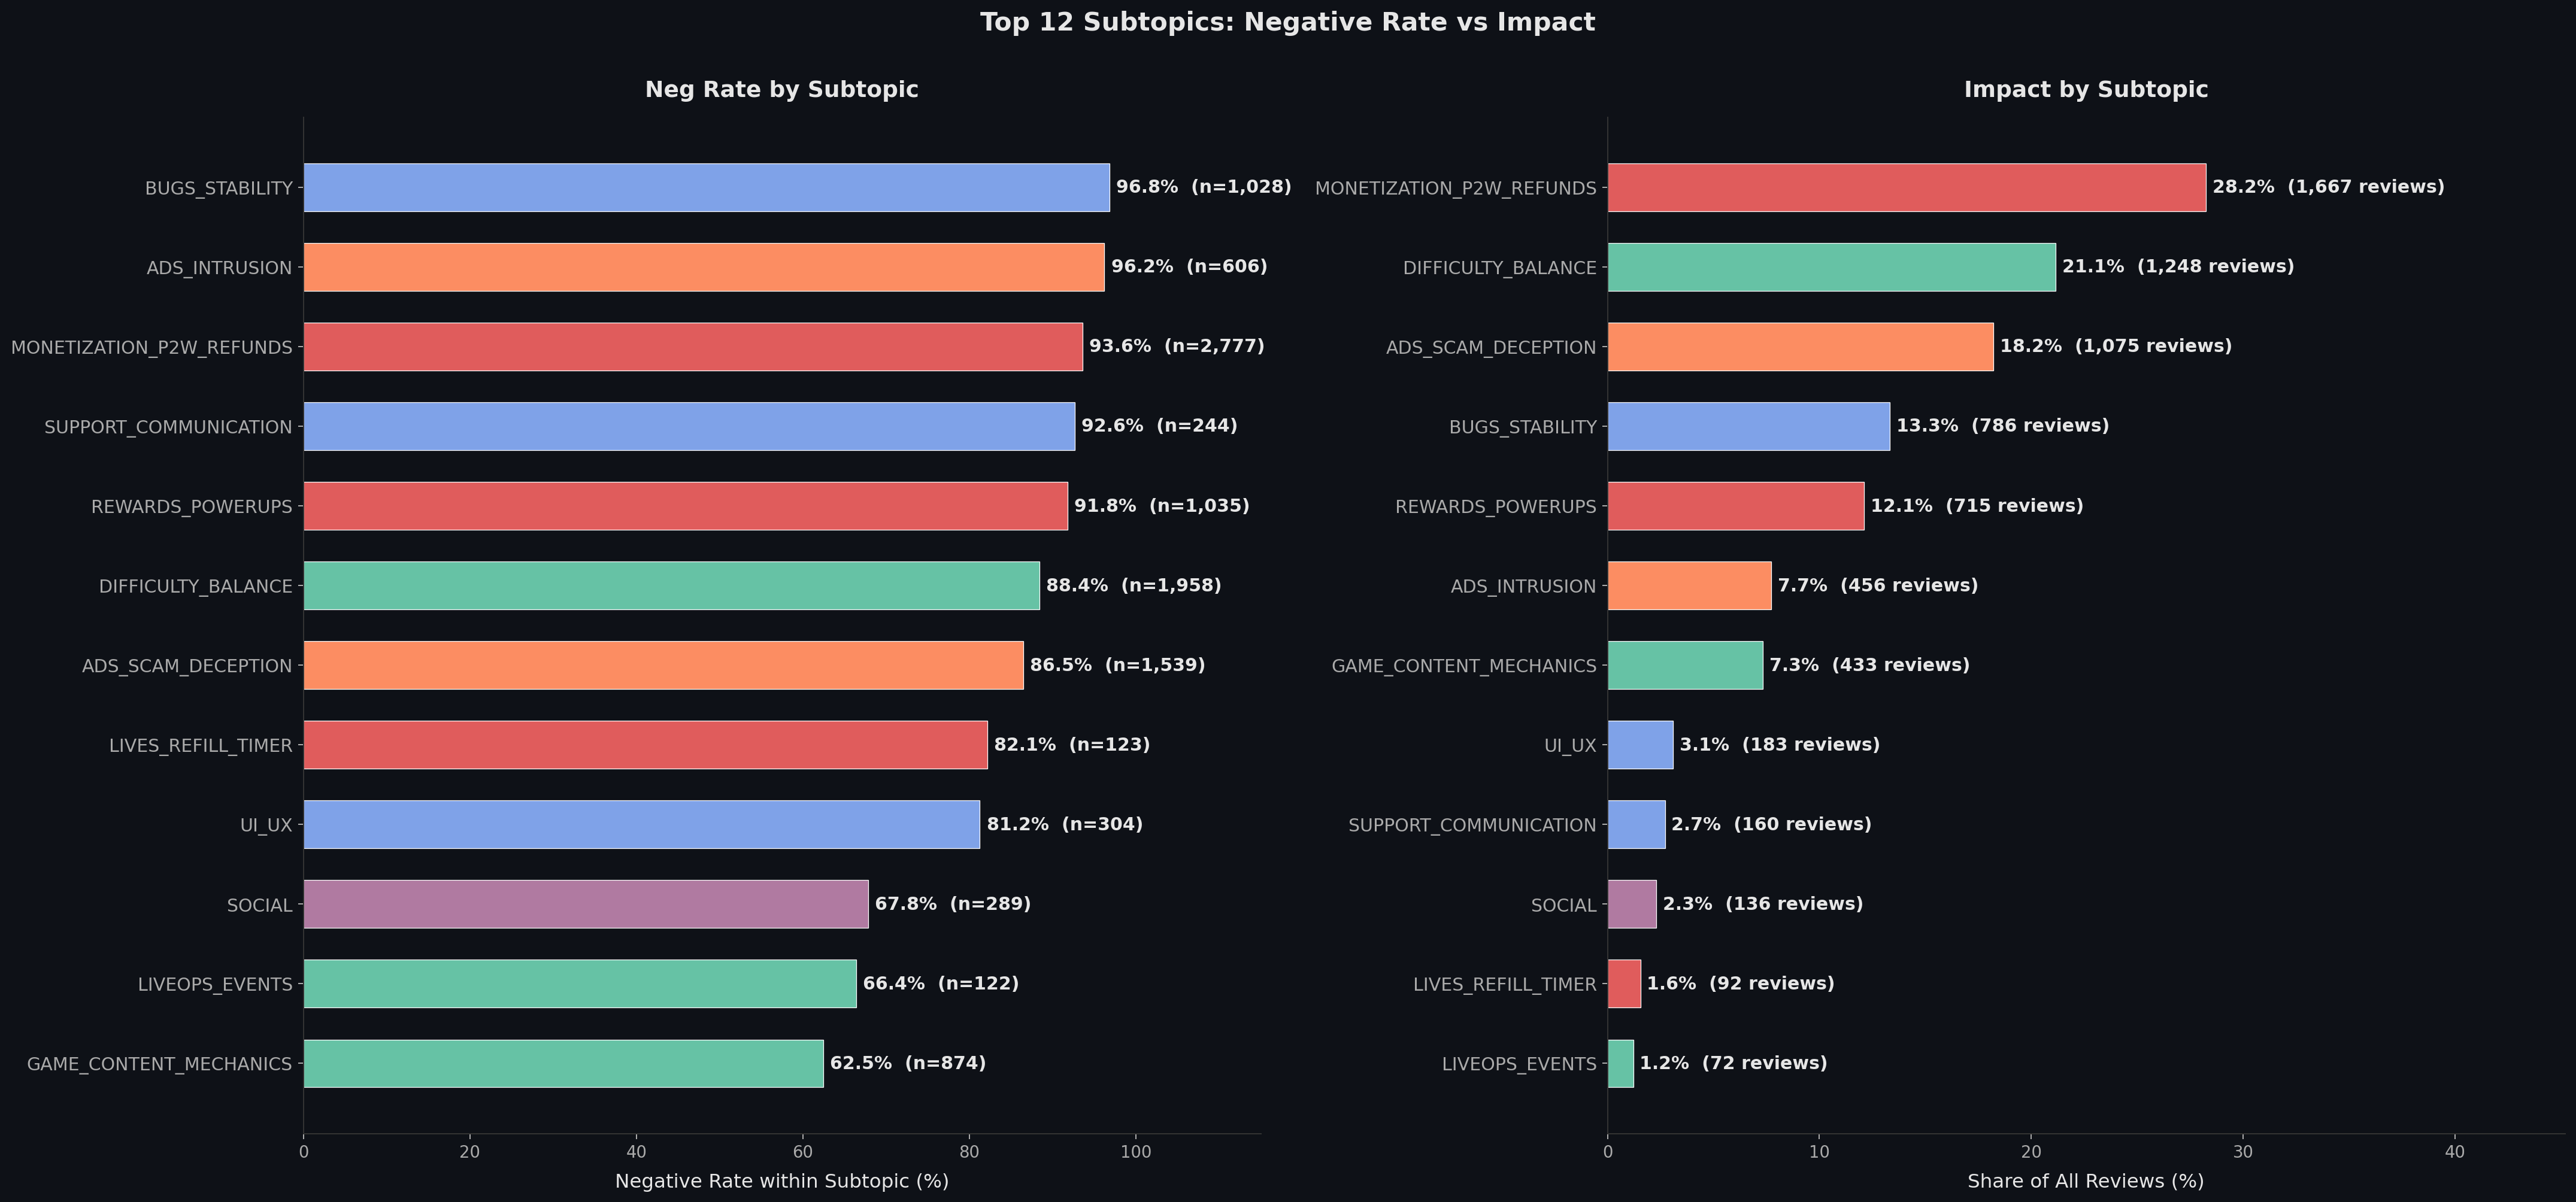

In [12]:
# =============================================================================
# STEP 03B — Subtopic-Level: Top Negative Impact Subtopics
# =============================================================================
section("3B — Subtopic Negative Rate & Impact (Top 12)")

df_seg_sub = df_segments[
    ~df_segments.subtopic.isin(["UNCLASSIFIED"]) &
    df_segments.subtopic.notna()
].copy()

# Per subtopic stats
sub_stats = []
for subtopic, sub in df_seg_sub.groupby("subtopic"):
    n_segments = len(sub)
    if n_segments == 0:
        continue
    n_reviews = sub.review_id.nunique()
    n_neg = (sub.seg_sentiment == "negative").sum()
    neg_rate = n_neg / n_segments
    neg_reviews = sub[sub.seg_sentiment == "negative"].review_id.nunique()
    impact = neg_reviews / total_reviews
    parent = sub.main_topic.value_counts().index[0]
    sub_stats.append({
        "subtopic": subtopic, "main_topic": parent,
        "n_segments": n_segments, "n_reviews": n_reviews,
        "neg_rate": neg_rate, "neg_reviews": neg_reviews, "impact": impact,
    })

df_sub = pd.DataFrame(sub_stats).set_index("subtopic")

# Top 12 by impact
top12 = df_sub.sort_values("impact", ascending=False).head(12)

print(top12[["main_topic", "n_segments", "n_reviews", "neg_rate", "neg_reviews", "impact"]].round(3).to_string())

# ── Chart ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11))

top12_nr = top12.sort_values("neg_rate", ascending=True)
top12_imp = top12.sort_values("impact", ascending=True)

# Left: neg rate
colors_nr = [TOPIC_PALETTE.get(t, "#6b7280") for t in top12_nr["main_topic"]]
bars1 = ax1.barh(top12_nr.index, top12_nr["neg_rate"] * 100,
                 color=colors_nr, edgecolor="white", linewidth=0.5, height=0.6)
for bar, val, n in zip(bars1, top12_nr["neg_rate"], top12_nr["n_segments"]):
    ax1.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f"{val*100:.1f}%  (n={n:,})", va="center", fontsize=12, fontweight="bold")

ax1.set_xlim(0, 115)
ax1.set_xlabel("Negative Rate within Subtopic (%)", fontsize=13, labelpad=8)
ax1.set_title("Neg Rate by Subtopic", fontsize=15, fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="y", labelsize=12)
ax1.tick_params(axis="x", labelsize=11)

# Right: impact
colors_imp = [TOPIC_PALETTE.get(t, "#6b7280") for t in top12_imp["main_topic"]]
bars2 = ax2.barh(top12_imp.index, top12_imp["impact"] * 100,
                 color=colors_imp, edgecolor="white", linewidth=0.5, height=0.6)
for bar, val, nr in zip(bars2, top12_imp["impact"], top12_imp["neg_reviews"]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val*100:.1f}%  ({nr:,} reviews)", va="center", fontsize=12, fontweight="bold")

ax2.set_xlim(0, top12["impact"].max() * 100 * 1.6)
ax2.set_xlabel("Share of All Reviews (%)", fontsize=13, labelpad=8)
ax2.set_title("Impact by Subtopic", fontsize=15, fontweight="bold", pad=14)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="x", labelsize=11)

plt.suptitle("Top 12 Subtopics: Negative Rate vs Impact",
             fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


3C — Topic Profile by Game (Segment Share %)


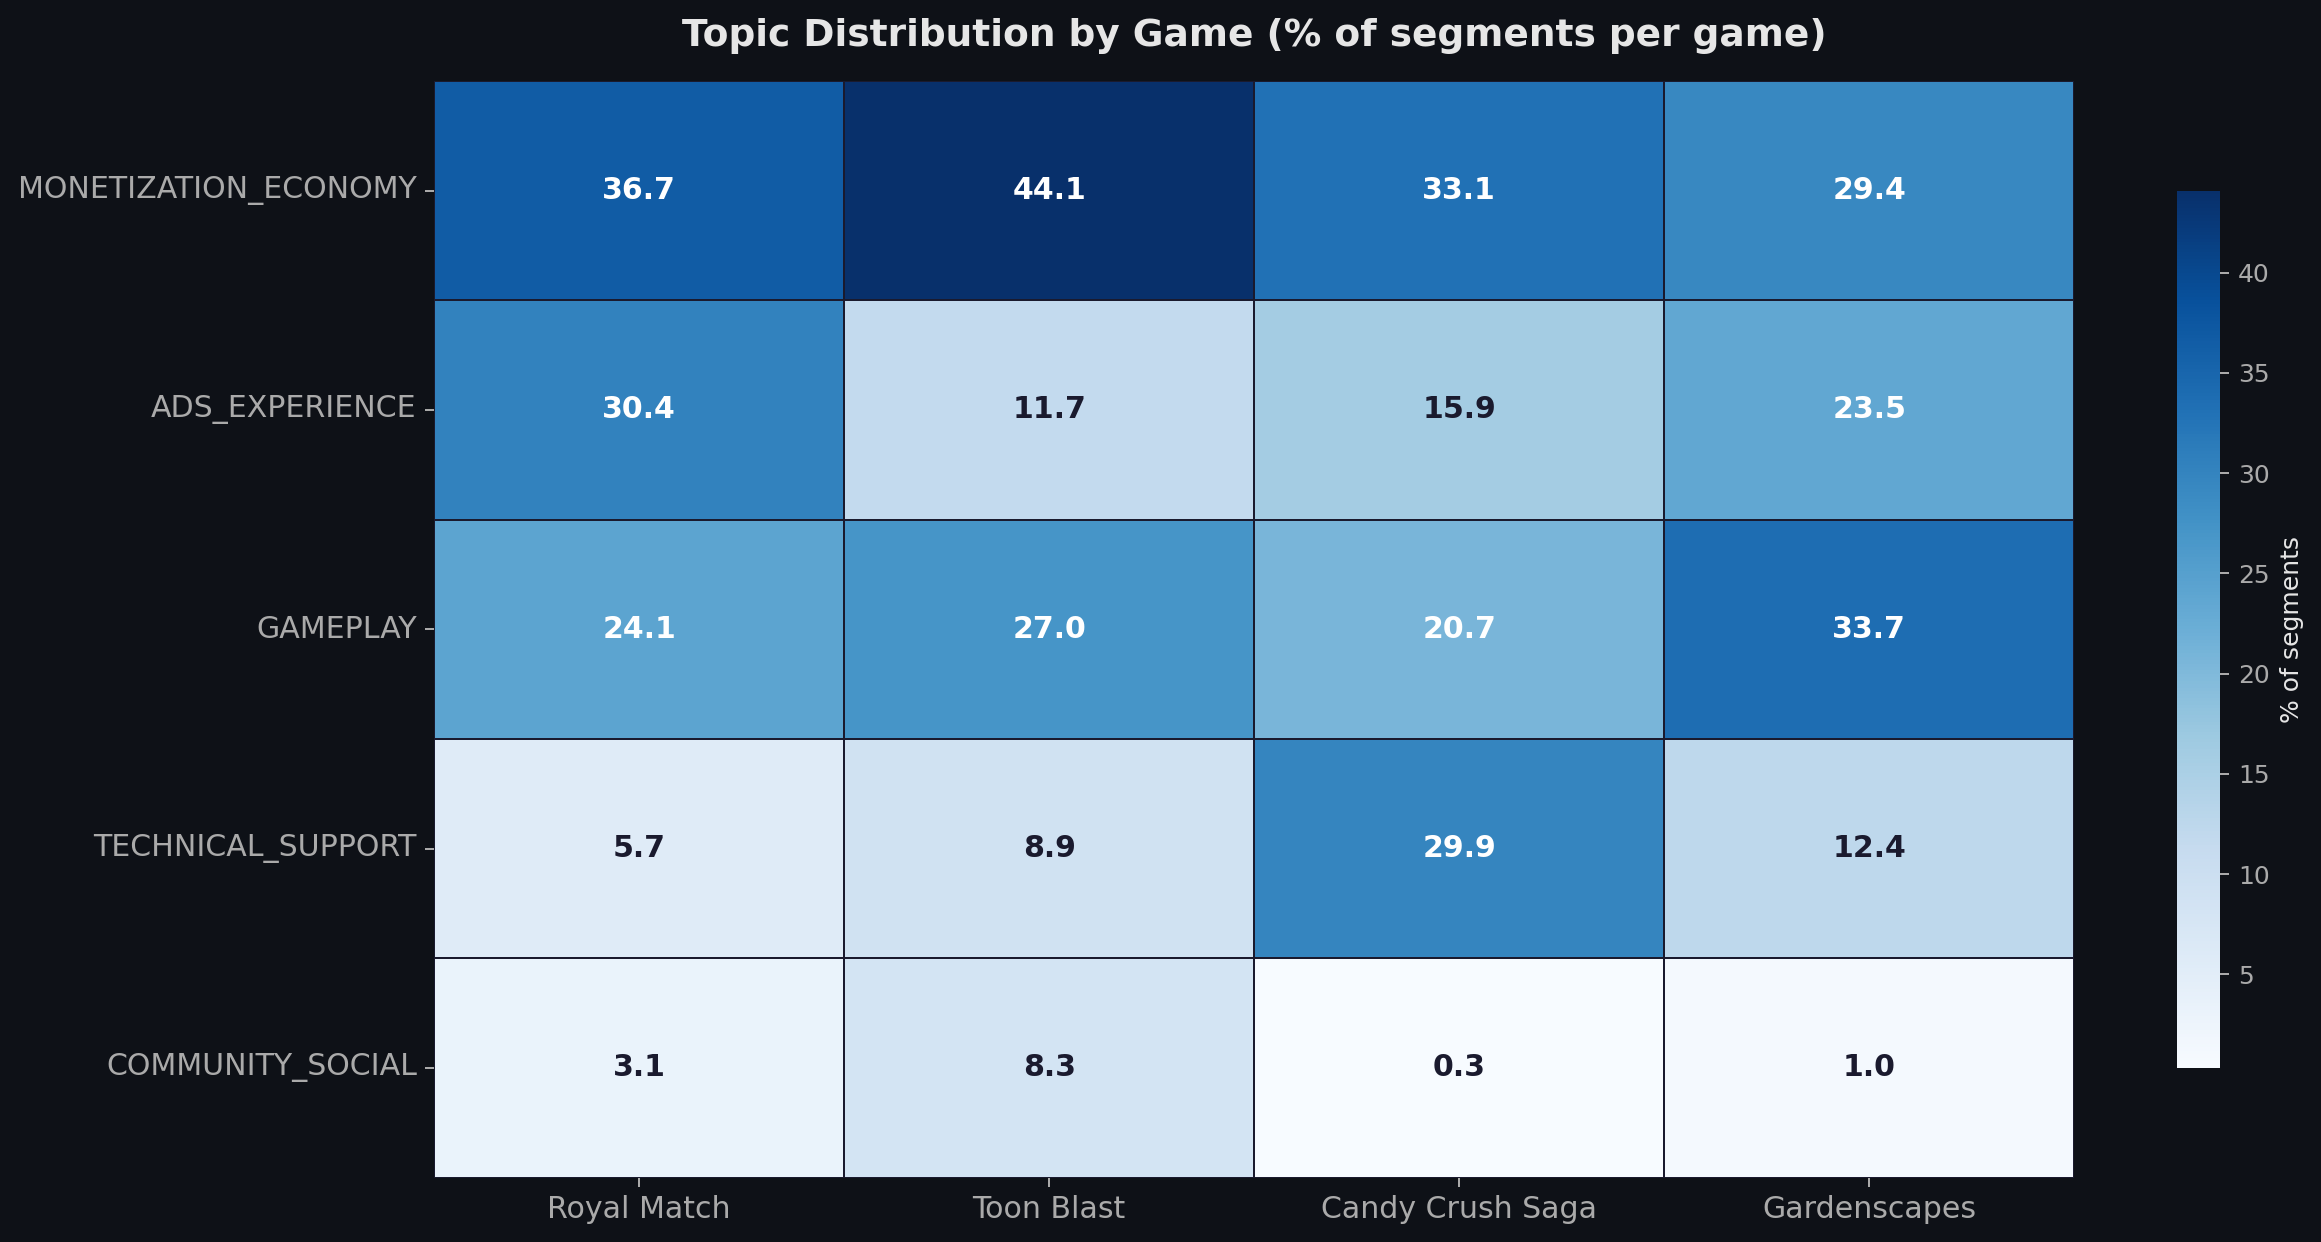


3C — Segment Counts
game                  Royal Match  Toon Blast  Candy Crush Saga  Gardenscapes
main_topic                                                                   
MONETIZATION_ECONOMY         1339         723              1000           873
ADS_EXPERIENCE               1110         192               482           699
GAMEPLAY                      881         443               627          1003
TECHNICAL_SUPPORT             208         146               903           368
COMMUNITY_SOCIAL              112         136                10            31


In [13]:
# =============================================================================
# STEP 03C — Topic Distribution by Game
# =============================================================================
section("3C — Topic Profile by Game (Segment Share %)")

# Normalized topic distribution per game
topic_game = (
    df_seg_clean.groupby(["game", "main_topic"])
    .size().reset_index(name="n")
)
topic_game["pct"] = (
    topic_game.groupby("game")["n"]
    .transform(lambda x: x / x.sum() * 100)
)

pivot = topic_game.pivot(index="main_topic", columns="game", values="pct").reindex(TOPIC_ORDER_CLEAN).reindex(columns=GAME_ORDER)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.8, linecolor="#1a1a2e",
    cbar_kws={"label": "% of segments", "shrink": 0.8},
    annot_kws={"fontweight": "bold", "fontsize": 12},
    ax=ax,
)

# Fix annotation colors
normed = (pivot.values - np.nanmin(pivot.values)) / (np.nanmax(pivot.values) - np.nanmin(pivot.values))
for i, text in enumerate(ax.texts):
    row, col = divmod(i, pivot.shape[1])
    text.set_color("white" if normed[row, col] > 0.4 else "#1a1a2e")

ax.set_title("Topic Distribution by Game (% of segments per game)", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("", fontsize=1)
ax.set_ylabel("", fontsize=1)
ax.tick_params(axis="y", labelsize=12, rotation=0)
ax.tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

# Print raw counts
section("3C — Segment Counts")
pivot_n = topic_game.pivot(index="main_topic", columns="game", values="n").reindex(TOPIC_ORDER_CLEAN).reindex(columns=GAME_ORDER)
print(pivot_n.to_string())


3D — Topic Profile by Country (Segment Share %)


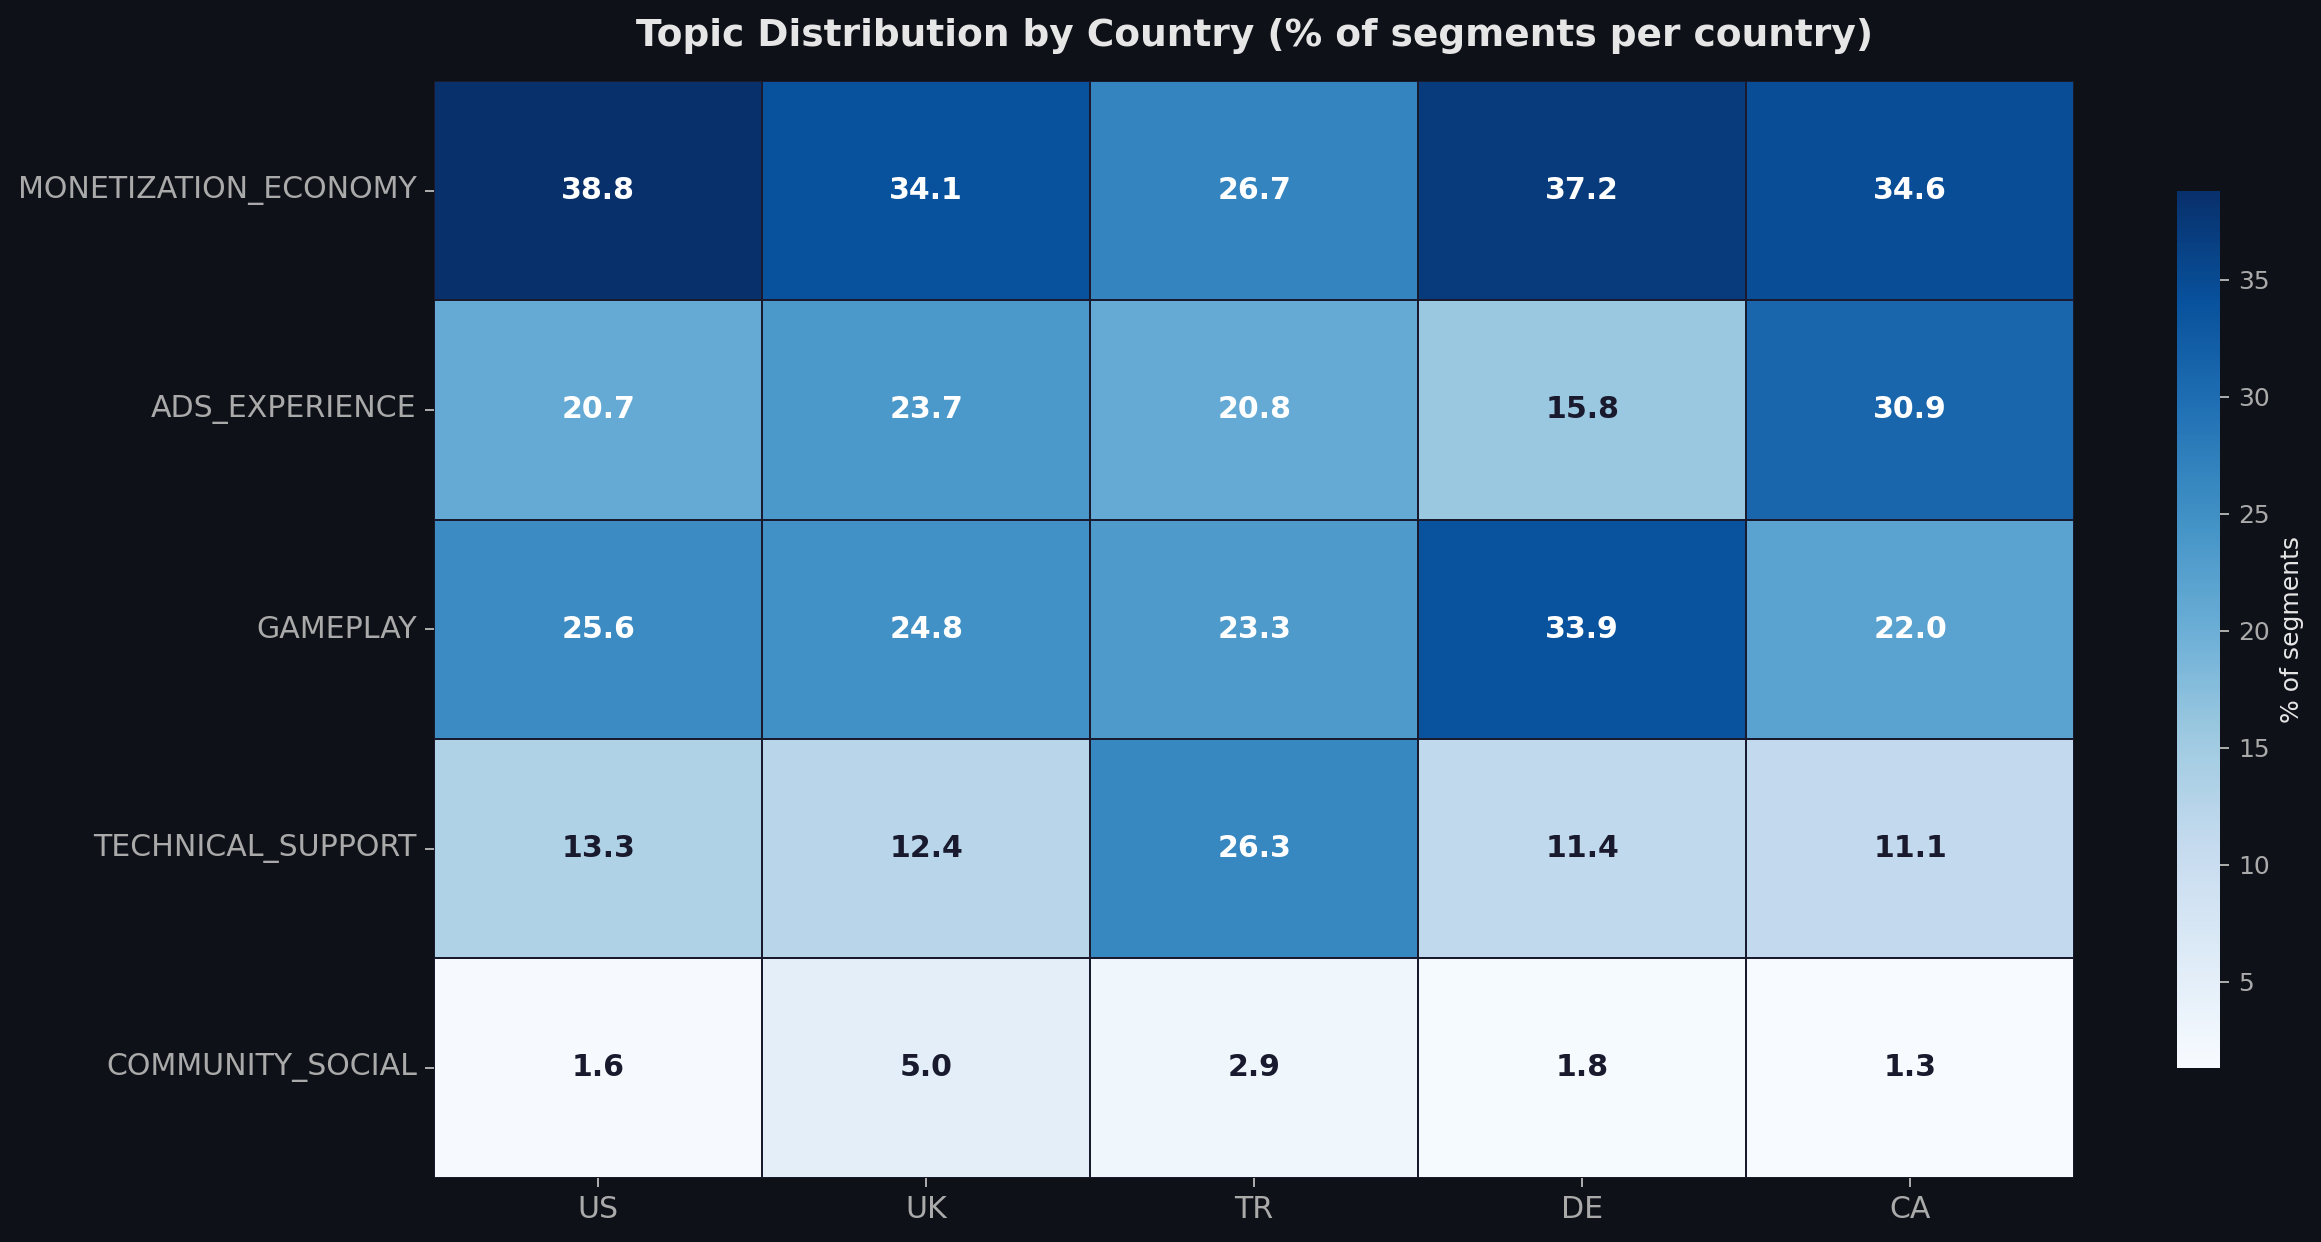

In [14]:
# =============================================================================
# STEP 03D — Topic Distribution by Country
# =============================================================================
section("3D — Topic Profile by Country (Segment Share %)")

topic_country = (
    df_seg_clean[df_seg_clean.country.isin(COUNTRY_ORDER)]
    .groupby(["country", "main_topic"])
    .size().reset_index(name="n")
)
topic_country["pct"] = (
    topic_country.groupby("country")["n"]
    .transform(lambda x: x / x.sum() * 100)
)

pivot_c = (
    topic_country.pivot(index="main_topic", columns="country", values="pct")
    .reindex(TOPIC_ORDER_CLEAN)
    .reindex(columns=COUNTRY_ORDER)
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    pivot_c, annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.8, linecolor="#1a1a2e",
    cbar_kws={"label": "% of segments", "shrink": 0.8},
    annot_kws={"fontweight": "bold", "fontsize": 12},
    ax=ax,
)

normed_c = (pivot_c.values - np.nanmin(pivot_c.values)) / (np.nanmax(pivot_c.values) - np.nanmin(pivot_c.values))
for i, text in enumerate(ax.texts):
    row, col = divmod(i, pivot_c.shape[1])
    text.set_color("white" if normed_c[row, col] > 0.4 else "#1a1a2e")

ax.set_xticklabels([COUNTRY_SHORT[c] for c in COUNTRY_ORDER], fontsize=12)
ax.set_title("Topic Distribution by Country (% of segments per country)", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("", fontsize=1)
ax.set_ylabel("", fontsize=1)
ax.tick_params(axis="y", labelsize=12, rotation=0)

plt.tight_layout()
plt.show()

### Step 03 — Summary

**Neg rate vs impact tells different stories.** TECHNICAL_SUPPORT has the highest neg rate (93.2%) but ranks 4th in impact (18.6%) — it's intensely negative but affects fewer reviews. MONETIZATION_ECONOMY dominates on both axes: 92.7% neg rate AND 36.0% impact — over a third of all reviews contain a negative monetization segment. This is the #1 product priority by any measure.

**Top 3 impact subtopics account for 67.5% of negative review volume:** MONETIZATION_P2W_REFUNDS (28.2%, 1,667 reviews), DIFFICULTY_BALANCE (21.1%, 1,248 reviews), and ADS_SCAM_DECEPTION (18.2%, 1,075 reviews). These three subtopics alone explain two-thirds of user dissatisfaction.

**BUGS_STABILITY is a silent killer:** 96.8% neg rate (highest of all subtopics) with 13.3% impact (786 reviews). Nearly every user who mentions bugs is negative — there is almost zero positive signal in this area.

**Games have distinct topic profiles.** Royal Match is disproportionately heavy on ADS_EXPERIENCE (30.4% vs 11.7% Toon Blast) — ad-related complaints are an RM-specific pain point. Candy Crush Saga leads in TECHNICAL_SUPPORT (29.9%) — stability/account issues are its differentiating problem. Toon Blast skews toward MONETIZATION (44.1%) and has the highest COMMUNITY_SOCIAL share (8.3%). These differences will be formally tested in H3.

**Country profiles diverge on key topics.** TR has a notably higher TECHNICAL_SUPPORT share (26.3% vs US 13.3%) and lower MONETIZATION (26.7% vs US 38.8%). Canada leads ADS_EXPERIENCE (30.9%). Germany is the most GAMEPLAY-focused market (33.9%). These structural differences suggest localized product strategies could be more effective than global ones.

## Step 04 — ABSA Value-Add Analysis

This step quantifies what **segment-level sentiment (ABSA) reveals that review-level sentiment misses**. Step 1 showed 86.3% agreement between the two layers — the remaining 13.7% disagreement is where ABSA adds value. Specifically, a review labeled "positive" overall may contain negative segments about specific topics — and vice versa.

**Sub-steps:**
- **4A** — Disagreement breakdown: which direction (positive review + negative segment vs negative review + positive segment) is more common?
- **4B** — Hidden negativity by topic: in reviews labeled "positive" overall, which topics carry negative segments?
- **4C** — Connecting ABSA to hidden dissatisfaction: among the 4-5★ hidden dissatisfied reviews, what does ABSA reveal at segment level?

The key table is `df_segments` which has both `review_sentiment` (review-level) and `seg_sentiment` (segment-level).


4A — Segment vs Review Sentiment Agreement
  Counts:
seg_sentiment     negative  positive    All
review_sentiment                           
negative             11027      1255  12282
positive               672      1153   1825
All                  11699      2408  14107

  Percentages:
seg_sentiment     negative  positive
review_sentiment                    
negative              78.2       8.9
positive               4.8       8.2

4A — Disagreement Direction
  Positive review + Negative segment : 672 (4.8%)
  Negative review + Positive segment : 1,255 (8.9%)
  Total disagreement                 : 1,927 (13.7%)


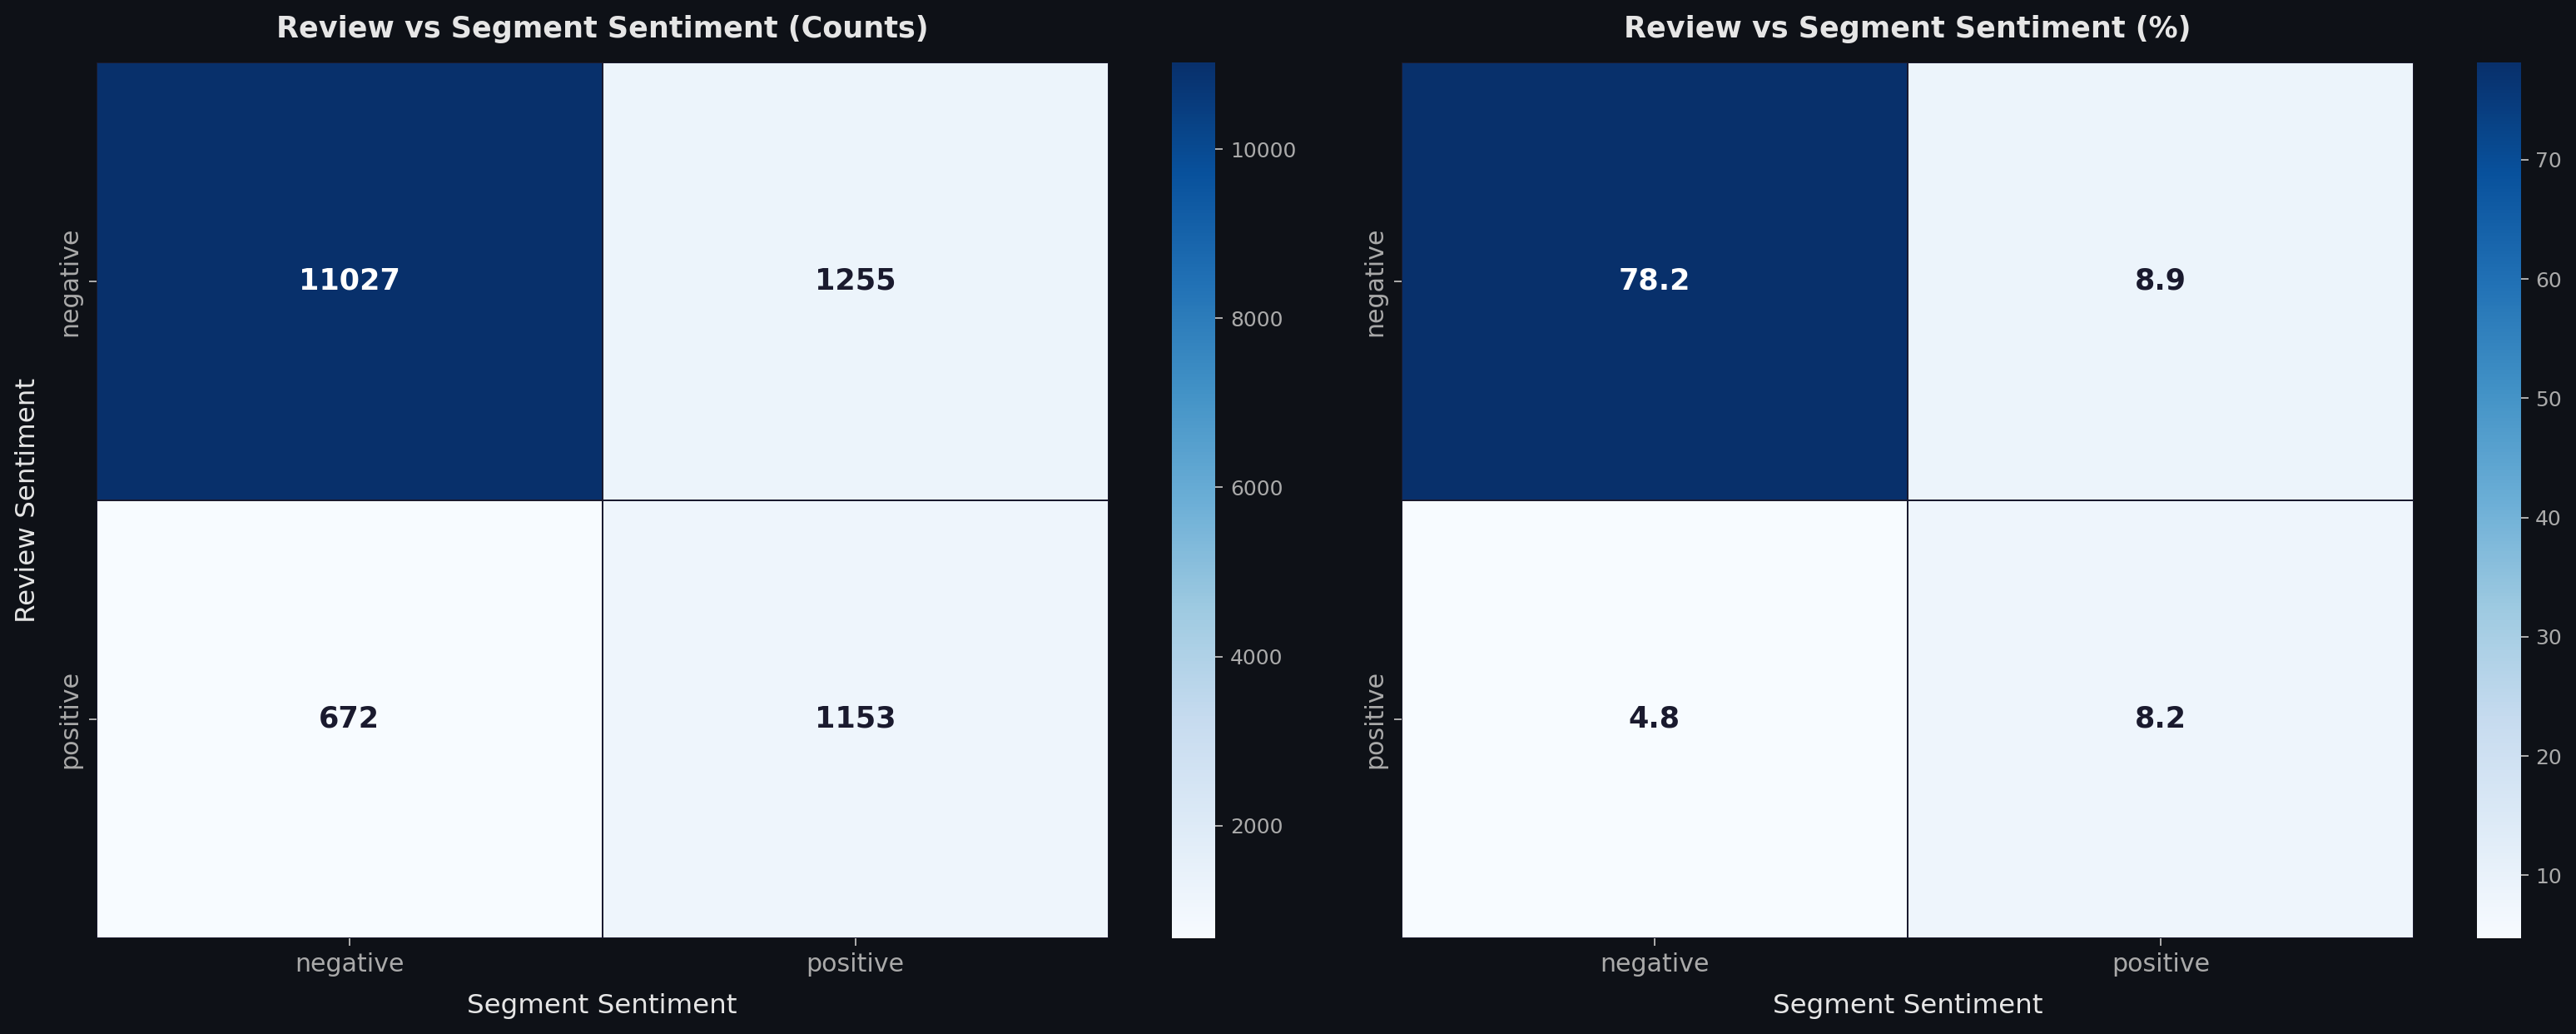

In [15]:
# =============================================================================
# STEP 04A — Segment vs Review Sentiment: Disagreement Breakdown
# =============================================================================
section("4A — Segment vs Review Sentiment Agreement")

# Confusion matrix: review_sentiment (rows) vs seg_sentiment (columns)
conf = pd.crosstab(
    df_segments["review_sentiment"],
    df_segments["seg_sentiment"],
    margins=True
)
conf_pct = pd.crosstab(
    df_segments["review_sentiment"],
    df_segments["seg_sentiment"],
    normalize="all"
).mul(100)

print("  Counts:")
print(conf.to_string())
print(f"\n  Percentages:")
print(conf_pct.round(1).to_string())

# Disagreement types
total_seg = len(df_segments)
pos_review_neg_seg = len(df_segments[
    (df_segments.review_sentiment == "positive") & (df_segments.seg_sentiment == "negative")
])
neg_review_pos_seg = len(df_segments[
    (df_segments.review_sentiment == "negative") & (df_segments.seg_sentiment == "positive")
])

section("4A — Disagreement Direction")
print(f"  Positive review + Negative segment : {pos_review_neg_seg:,} ({pos_review_neg_seg/total_seg*100:.1f}%)")
print(f"  Negative review + Positive segment : {neg_review_pos_seg:,} ({neg_review_pos_seg/total_seg*100:.1f}%)")
print(f"  Total disagreement                 : {pos_review_neg_seg + neg_review_pos_seg:,} ({(pos_review_neg_seg + neg_review_pos_seg)/total_seg*100:.1f}%)")

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Counts
conf_no_margin = pd.crosstab(df_segments["review_sentiment"], df_segments["seg_sentiment"])
sns.heatmap(conf_no_margin, annot=True, fmt="d", cmap="Blues",
            linewidths=0.8, linecolor="#1a1a2e",
            annot_kws={"fontweight": "bold", "fontsize": 14}, ax=ax1)
normed1 = (conf_no_margin.values - conf_no_margin.values.min()) / (conf_no_margin.values.max() - conf_no_margin.values.min())
for i, text in enumerate(ax1.texts):
    row, col = divmod(i, conf_no_margin.shape[1])
    text.set_color("white" if normed1[row, col] > 0.4 else "#1a1a2e")

ax1.set_title("Review vs Segment Sentiment (Counts)", fontsize=14, fontweight="bold", pad=12)
ax1.set_xlabel("Segment Sentiment", fontsize=13, labelpad=8)
ax1.set_ylabel("Review Sentiment", fontsize=13, labelpad=8)
ax1.tick_params(labelsize=12)

# Percentages
sns.heatmap(conf_pct, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.8, linecolor="#1a1a2e",
            annot_kws={"fontweight": "bold", "fontsize": 14}, ax=ax2)
normed2 = (conf_pct.values - conf_pct.values.min()) / (conf_pct.values.max() - conf_pct.values.min())
for i, text in enumerate(ax2.texts):
    row, col = divmod(i, conf_pct.shape[1])
    text.set_color("white" if normed2[row, col] > 0.4 else "#1a1a2e")

ax2.set_title("Review vs Segment Sentiment (%)", fontsize=14, fontweight="bold", pad=12)
ax2.set_xlabel("Segment Sentiment", fontsize=13, labelpad=8)
ax2.set_ylabel("")
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


4B — In Positive Reviews, Which Topics Carry Negative Segments?
  Total positive-review + negative-segment cases: 529
  Unique reviews involved: 360

                      n_segments  n_reviews        pct
main_topic                                            
GAMEPLAY                     202        162  38.185255
MONETIZATION_ECONOMY         126         99  23.818526
ADS_EXPERIENCE               110         96  20.793951
TECHNICAL_SUPPORT             74         52  13.988658
COMMUNITY_SOCIAL              17         16   3.213611


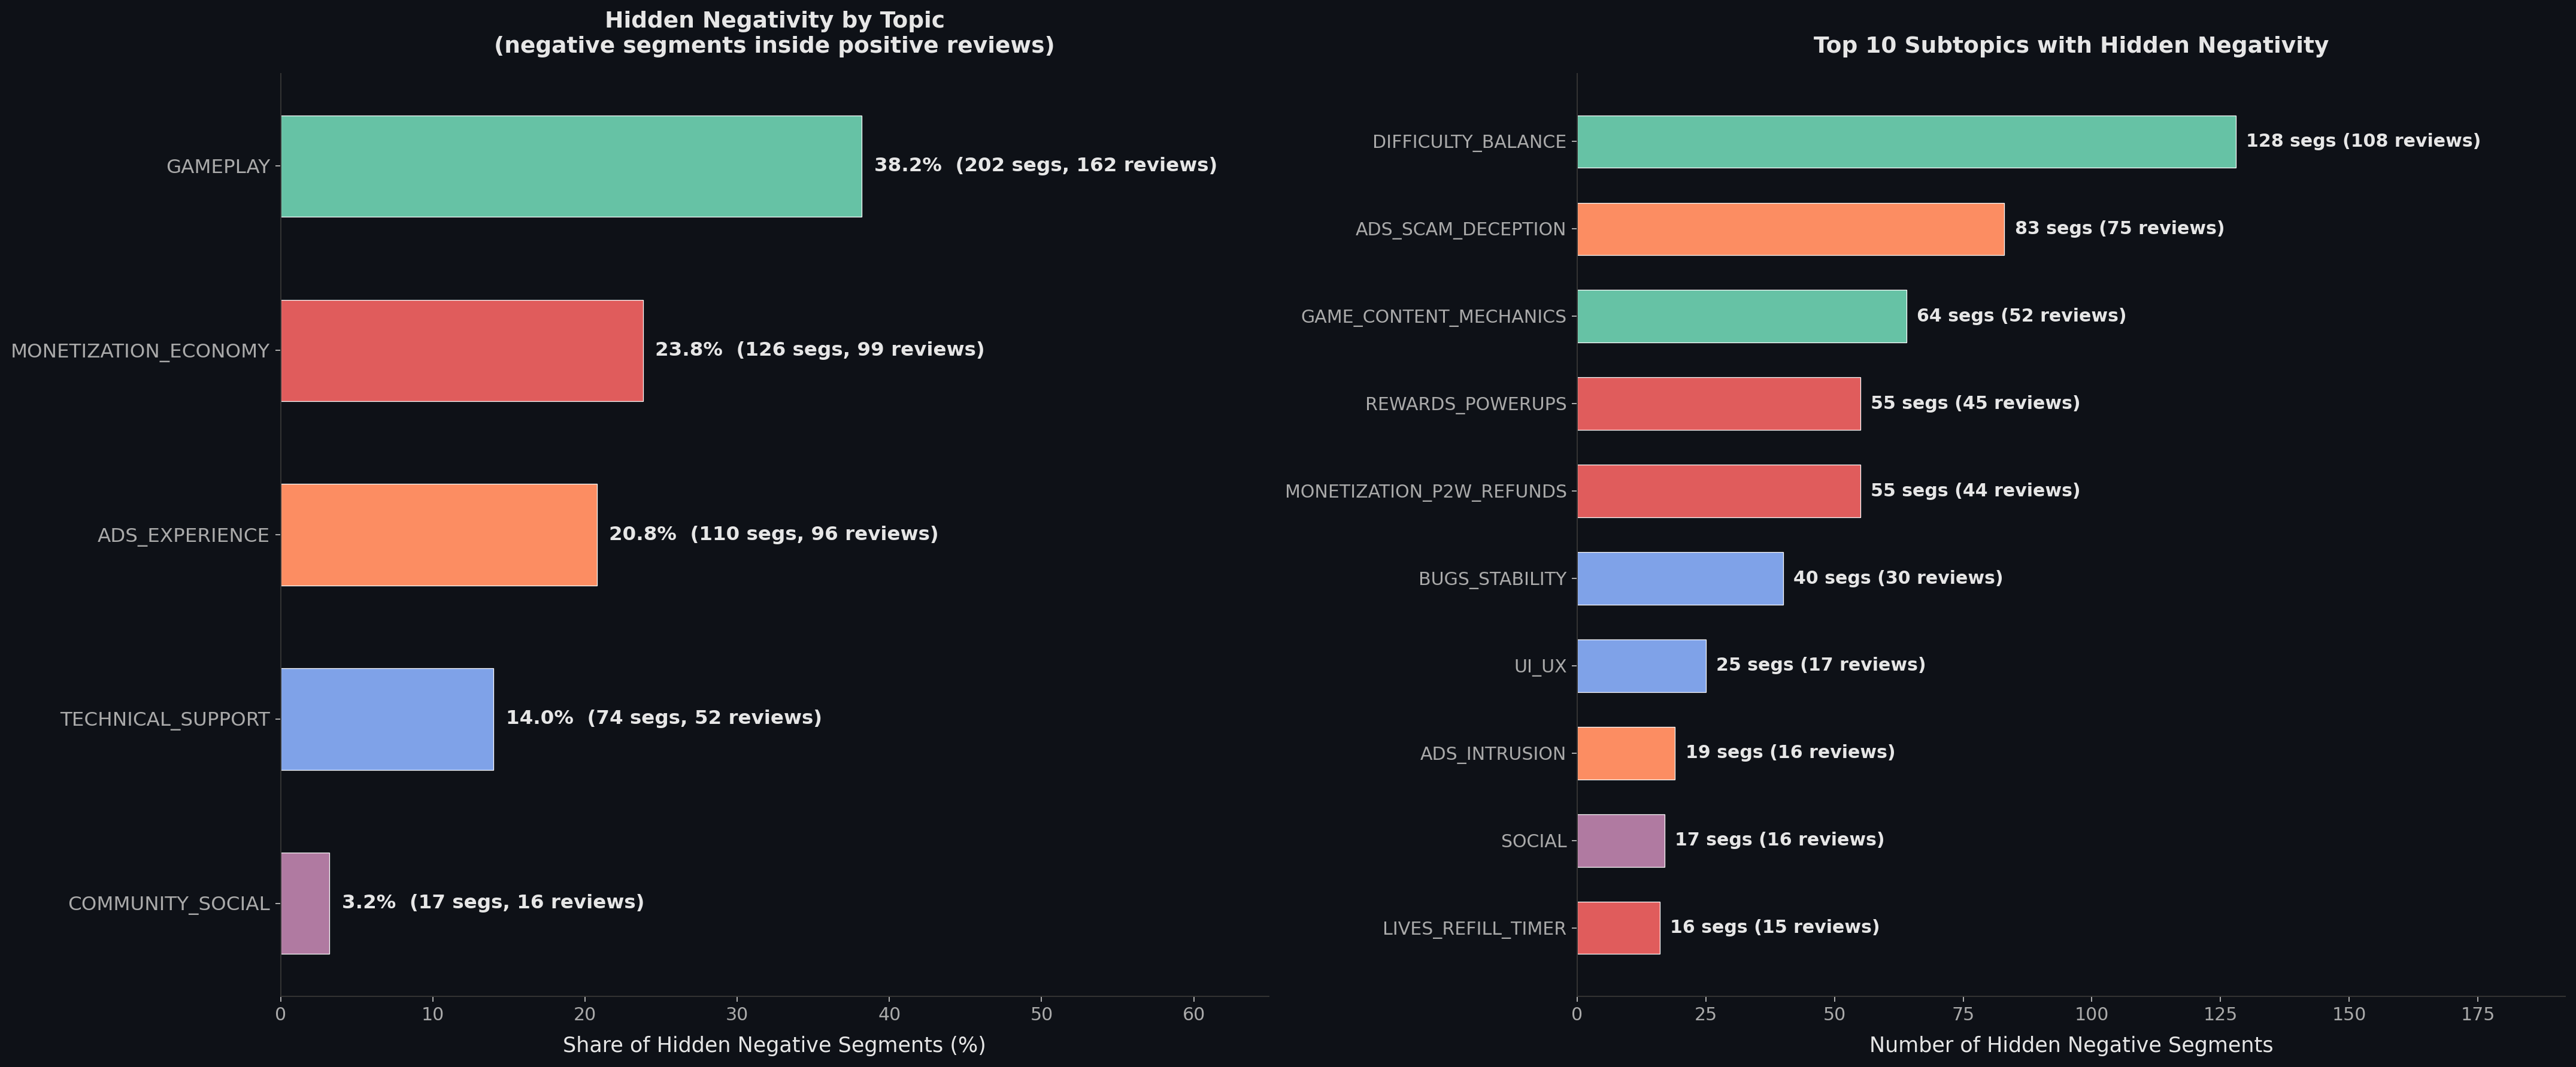

In [16]:
# =============================================================================
# STEP 04B — Hidden Negativity by Topic (Positive Reviews with Negative Segments)
# =============================================================================
section("4B — In Positive Reviews, Which Topics Carry Negative Segments?")

# Segments from positive reviews that are negative at segment level
pos_neg = df_segments[
    (df_segments.review_sentiment == "positive") &
    (df_segments.seg_sentiment == "negative") &
    (~df_segments.main_topic.isin(["UNASSIGNED", "OTHER"]))
].copy()

print(f"  Total positive-review + negative-segment cases: {len(pos_neg):,}")
print(f"  Unique reviews involved: {pos_neg.review_id.nunique():,}\n")

# Topic distribution of these hidden negative segments
hidden_by_topic = (
    pos_neg.groupby("main_topic")
    .agg(n_segments=("segment_id", "count"),
         n_reviews=("review_id", "nunique"))
    .sort_values("n_segments", ascending=False)
)
hidden_by_topic["pct"] = hidden_by_topic["n_segments"] / hidden_by_topic["n_segments"].sum() * 100

print(hidden_by_topic.to_string())

# Subtopic breakdown
hidden_by_sub = (
    pos_neg.groupby(["main_topic", "subtopic"])
    .agg(n_segments=("segment_id", "count"),
         n_reviews=("review_id", "nunique"))
    .sort_values("n_segments", ascending=False)
    .head(10)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Left: by main topic
colors = [TOPIC_PALETTE.get(t, "#6b7280") for t in hidden_by_topic.index]
bars = ax1.barh(hidden_by_topic.index, hidden_by_topic["pct"],
                color=colors, edgecolor="white", linewidth=0.5, height=0.55)
for bar, pct, n, nr in zip(bars, hidden_by_topic["pct"], hidden_by_topic["n_segments"], hidden_by_topic["n_reviews"]):
    ax1.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f"{pct:.1f}%  ({n} segs, {nr} reviews)", va="center", fontsize=13, fontweight="bold")

ax1.set_xlim(0, hidden_by_topic["pct"].max() * 1.7)
ax1.set_xlabel("Share of Hidden Negative Segments (%)", fontsize=14, labelpad=8)
ax1.set_title("Hidden Negativity by Topic\n(negative segments inside positive reviews)", fontsize=15, fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="y", labelsize=13)
ax1.tick_params(axis="x", labelsize=12)
ax1.invert_yaxis()

# Right: top 10 subtopics
hidden_by_sub_plot = hidden_by_sub.sort_values("n_segments", ascending=True)
colors_sub = [TOPIC_PALETTE.get(t, "#6b7280") for t in hidden_by_sub_plot.index.get_level_values("main_topic")]
bars2 = ax2.barh(
    [f"{sub}" for _, sub in hidden_by_sub_plot.index],
    hidden_by_sub_plot["n_segments"],
    color=colors_sub, edgecolor="white", linewidth=0.5, height=0.6
)
for bar, n, nr in zip(bars2, hidden_by_sub_plot["n_segments"], hidden_by_sub_plot["n_reviews"]):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{n} segs ({nr} reviews)", va="center", fontsize=12, fontweight="bold")

ax2.set_xlim(0, hidden_by_sub_plot["n_segments"].max() * 1.5)
ax2.set_xlabel("Number of Hidden Negative Segments", fontsize=14, labelpad=8)
ax2.set_title("Top 10 Subtopics with Hidden Negativity", fontsize=15, fontweight="bold", pad=14)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()


4C — ABSA View of Hidden Dissatisfied Reviews (4-5★ + Negative Sentiment)
  Hidden dissatisfied reviews with segments: 531
  Total segments in these reviews: 1,064

  Topic breakdown of hidden dissatisfied reviews:
                      n_segments  n_neg  n_pos  n_reviews  neg_rate
main_topic                                                         
MONETIZATION_ECONOMY         320    292     28        197  0.912500
GAMEPLAY                     317    265     52        209  0.835962
TECHNICAL_SUPPORT            197    193      4        148  0.979695
ADS_EXPERIENCE               188    158     30        142  0.840426
COMMUNITY_SOCIAL              42     35      7         25  0.833333


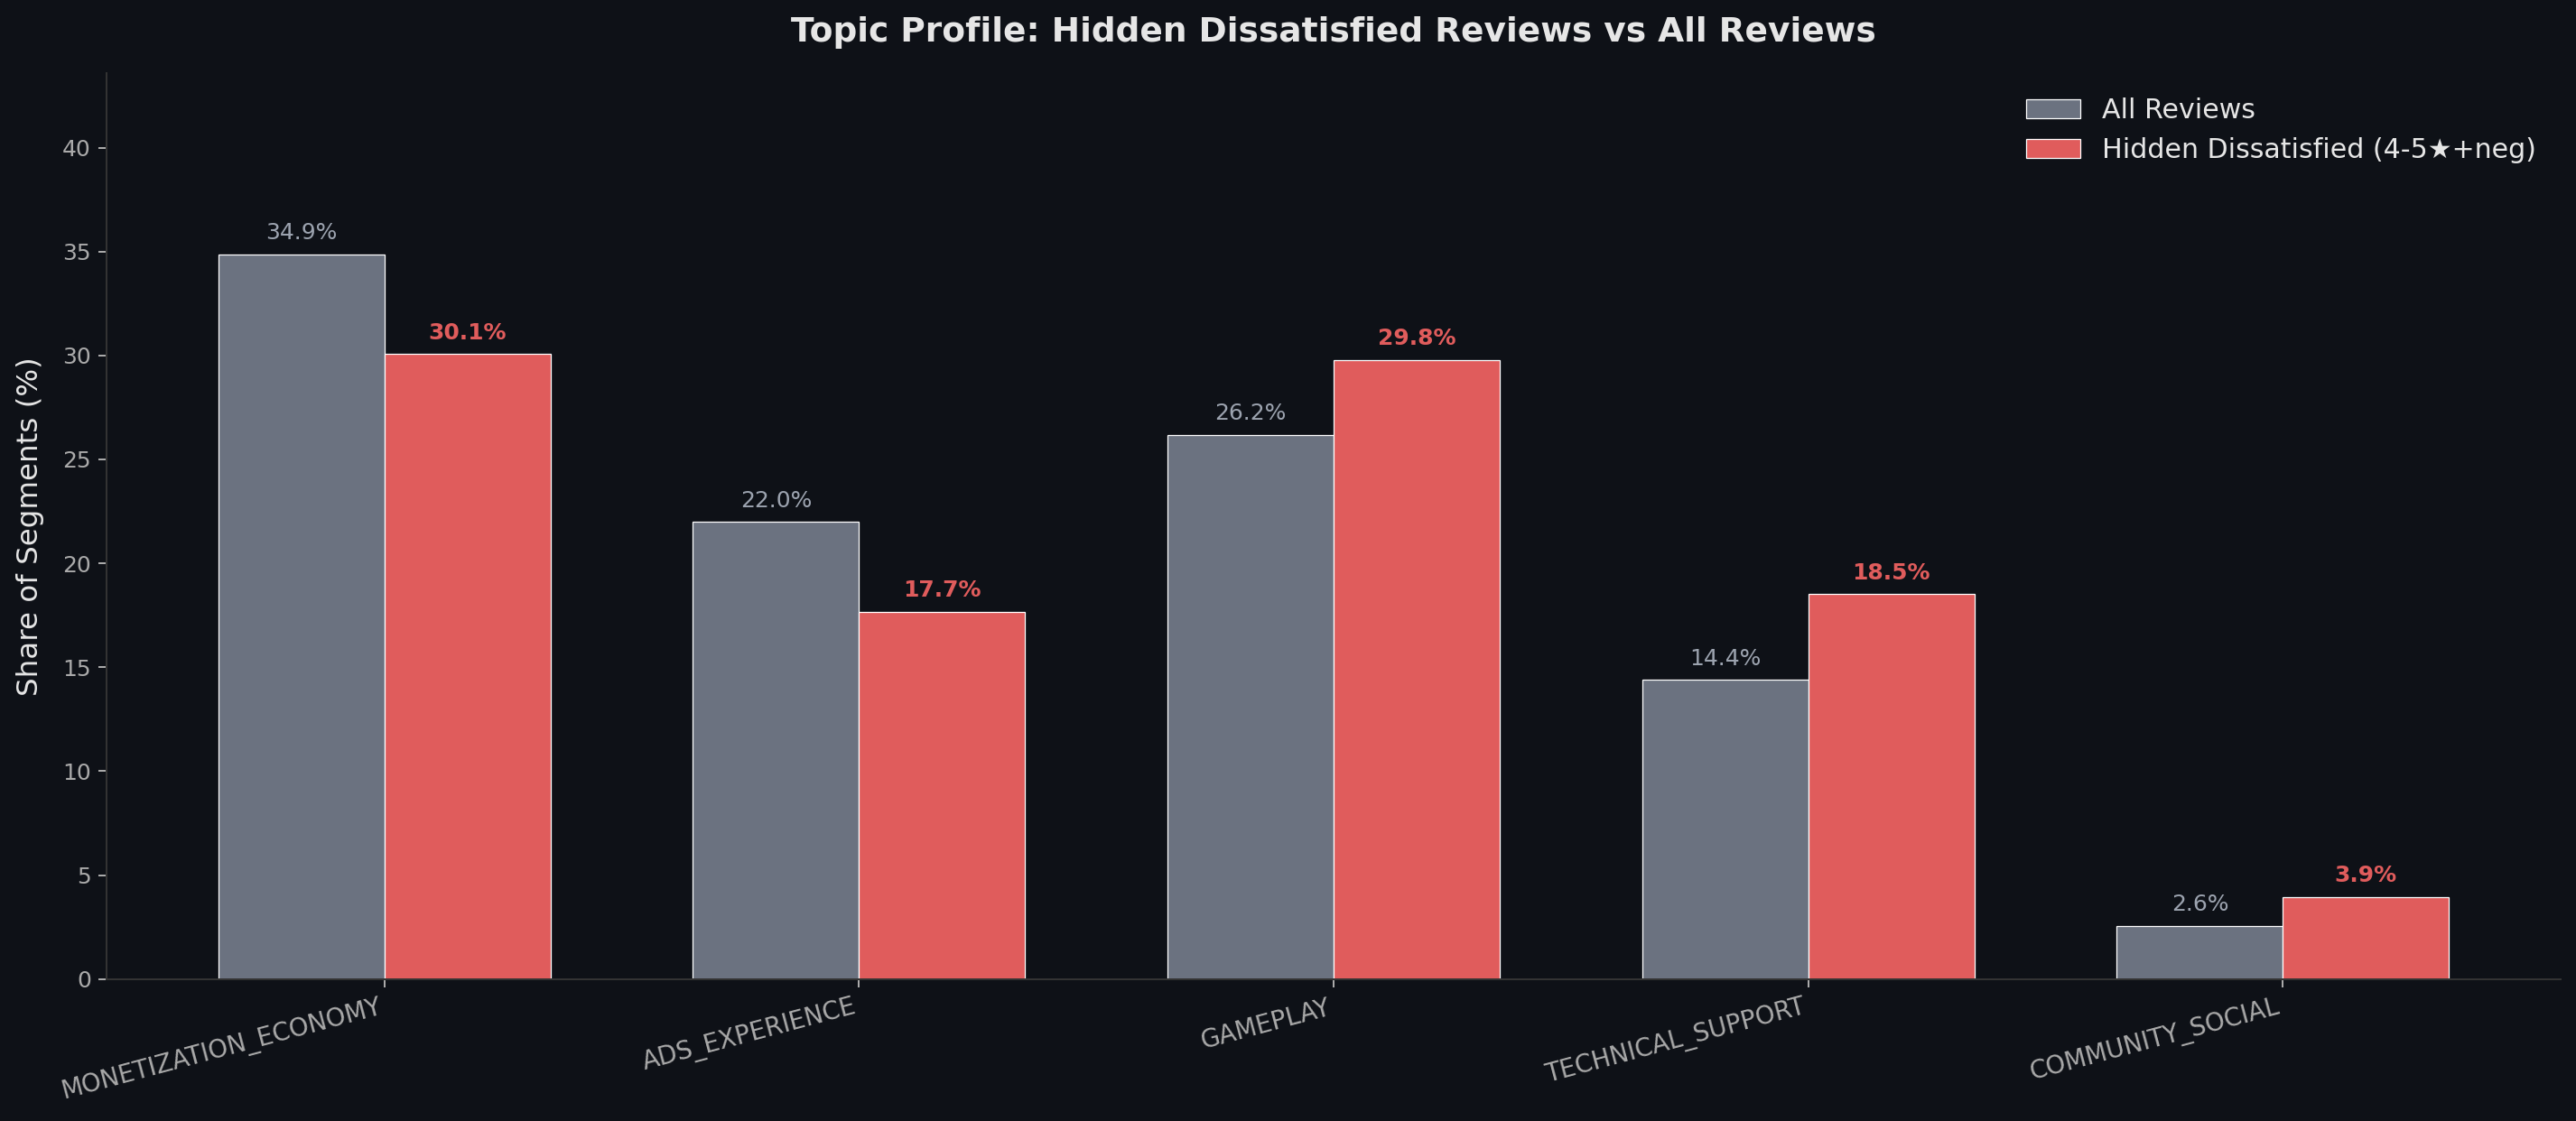

In [17]:
# =============================================================================
# STEP 04C — ABSA Deep Dive on Hidden Dissatisfaction (4-5★ + Negative)
# =============================================================================
section("4C — ABSA View of Hidden Dissatisfied Reviews (4-5★ + Negative Sentiment)")

# Segments from high-rating reviews with negative review sentiment
hd_segs = df_segments[
    (df_segments.rating >= 4) &
    (df_segments.review_sentiment == "negative") &
    (~df_segments.main_topic.isin(["UNASSIGNED", "OTHER"]))
].copy()

total_hd_reviews = hd_segs.review_id.nunique()
print(f"  Hidden dissatisfied reviews with segments: {total_hd_reviews:,}")
print(f"  Total segments in these reviews: {len(hd_segs):,}\n")

# What topics appear in these reviews?
hd_topic = (
    hd_segs.groupby("main_topic")
    .agg(n_segments=("segment_id", "count"),
         n_neg=("seg_sentiment", lambda x: (x == "negative").sum()),
         n_pos=("seg_sentiment", lambda x: (x == "positive").sum()),
         n_reviews=("review_id", "nunique"))
    .assign(neg_rate=lambda d: d.n_neg / d.n_segments)
    .sort_values("n_segments", ascending=False)
)

print("  Topic breakdown of hidden dissatisfied reviews:")
print(hd_topic.to_string())

# ── Chart: topic distribution comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Hidden dissatisfied vs overall topic distribution
all_topic_dist = (
    df_segments[~df_segments.main_topic.isin(["UNASSIGNED", "OTHER"])]
    .main_topic.value_counts(normalize=True).mul(100)
    .reindex(TOPIC_ORDER_CLEAN).fillna(0)
)
hd_topic_dist = (
    hd_segs.main_topic.value_counts(normalize=True).mul(100)
    .reindex(TOPIC_ORDER_CLEAN).fillna(0)
)

x = np.arange(len(TOPIC_ORDER_CLEAN))
w = 0.35
bars1 = ax.bar(x - w/2, all_topic_dist.values, w, label="All Reviews",
               color="#6b7280", edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x + w/2, hd_topic_dist.values, w, label="Hidden Dissatisfied (4-5★+neg)",
               color="#E05C5C", edgecolor="white", linewidth=0.5)

for bar, val in zip(bars1, all_topic_dist.values):
    if val > 2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, color="#9ca3af")
for bar, val in zip(bars2, hd_topic_dist.values):
    if val > 2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#E05C5C")

ax.set_xticks(x)
ax.set_xticklabels(TOPIC_ORDER_CLEAN, fontsize=11, rotation=15, ha="right")
ax.set_ylabel("Share of Segments (%)", fontsize=13, labelpad=8)
ax.set_title("Topic Profile: Hidden Dissatisfied Reviews vs All Reviews",
             fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=12, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(all_topic_dist.max(), hd_topic_dist.max()) * 1.25)

plt.tight_layout()
plt.show()

### Step 04 — Summary

**ABSA adds 13.7% more signal than review-level sentiment.** Of 14,107 segments, 1,927 disagree with their parent review's sentiment. The disagreement is asymmetric: "negative review + positive segment" (8.9%) is nearly double "positive review + negative segment" (4.8%) — meaning even unhappy users acknowledge specific positives. ABSA captures this nuance that a single review-level label flattens.

**Hidden negativity shifts from MONETIZATION to GAMEPLAY.** In the overall dataset, MONETIZATION is the dominant complaint topic (36% impact). But inside positive reviews, the hidden negative segments are led by **GAMEPLAY (38.2%)**, followed by MONETIZATION (23.8%) and ADS (20.8%). The top subtopic is DIFFICULTY_BALANCE (128 segments, 108 reviews) — users who like the game overall still complain about difficulty. This is a silent product risk invisible to review-level analysis.

**Hidden dissatisfied users over-index on GAMEPLAY and TECHNICAL_SUPPORT.** Comparing the topic profile of 4-5★ negative reviews (531 reviews) to all reviews: GAMEPLAY is +3.6pp higher, TECHNICAL_SUPPORT is +4.1pp higher, while MONETIZATION is -4.8pp lower. Monetization and ads complaints are "loud" — they drive low ratings directly. But difficulty tuning and technical issues are "quiet" — users still give high ratings despite these frustrations, making them detectable only through ABSA.

**Practical implication:** A product team using only review-level sentiment would correctly prioritize monetization and ads fixes (they dominate negative volume). But they would miss that satisfied users are silently frustrated with difficulty balance and bugs — the exact areas where intervention could prevent future churn before it shows up in ratings.

## Step 05 — Hypothesis Testing

Seven formal hypothesis tests to statistically validate patterns observed in Steps 2–4. All tests use α = 0.05. Effect sizes are reported alongside p-values — statistical significance alone does not imply practical relevance. All tests are non-parametric — no normality assumption required.

| # | Question | Test | Data |
|---|----------|------|------|
| **H1a** | Does sentiment drop after the v32672 update (Dec 8)? | Mann-Whitney U | `df_reviews` (RM, pre/post window) |
| **H1b** | Does sentiment improve after the v32131 update (Oct 27)? | Mann-Whitney U | `df_reviews` (RM, pre/post window) |
| **H2** | Do specific topics significantly affect rating? | Kruskal-Wallis + Dunn post-hoc | `df_segments` (main_topic × rating) |
| **H3** | Is topic distribution different across games? | Chi-square | `df_segments` (game × main_topic) |
| **H4** | Does hidden dissatisfaction (4-5★ + neg) concentrate in specific topics? | Chi-square | `df_segments` + `df_reviews` |
| **H5** | Is sentiment distribution different across countries? | Chi-square | `df_reviews` (country × ml_sentiment) |
| **H6** | Is Royal Match's hidden dissatisfaction rate different from competitors? | Chi-square + Proportion z-test | `df_reviews` (game × hidden_dissatisfied) |

In [18]:
# =============================================================================
# H1 — Does sentiment change after key updates?
# Mann-Whitney U: pre-update vs post-update negative rate
#
# NOTE: Version numbers in this dataset reflect the App Store's current app
# version at the time of review submission — NOT the version the user actually
# has installed. Pre/post windows are approximations based on store-level
# version changes, not user-level update events.
# =============================================================================

# Encode sentiment as numeric: negative=1, positive=0
df_reviews["sent_numeric"] = (df_reviews["ml_sentiment"] == "negative").astype(int)
rm = df_reviews[df_reviews.game == "Royal Match"].copy()

def test_update_impact(version, label, direction="greater"):
    """Test whether sentiment shifts after a specific version update."""
    section(f"H1 — {label} (v{version})")
    
    version_dates = rm[rm.version == version]["date"]
    if len(version_dates) == 0:
        print(f"  Version {version} not found.")
        return None
    
    event_date = version_dates.min()
    print(f"  Version {version} first seen: {event_date.date()}")
    
    pre = rm[(rm.date >= event_date - pd.Timedelta(days=14)) & (rm.date < event_date)]
    post = rm[(rm.date >= event_date) & (rm.date <= event_date + pd.Timedelta(days=7))]
    
    print(f"  Pre-window  (t-14 to t-1): {len(pre)} reviews, neg_rate = {pre.sent_numeric.mean():.3f}")
    print(f"  Post-window (t+0 to t+7) : {len(post)} reviews, neg_rate = {post.sent_numeric.mean():.3f}")
    
    stat, p = stats.mannwhitneyu(post["sent_numeric"], pre["sent_numeric"], alternative=direction)
    
    n1, n2 = len(post), len(pre)
    r = 1 - (2 * stat) / (n1 * n2)
    
    dir_label = "worse (more negative)" if direction == "greater" else "better (less negative)"
    print(f"\n  H₀: Post-update sentiment is not {dir_label}")
    print(f"  H₁: Post-update sentiment is {dir_label}")
    print(f"  U-statistic : {stat:,.0f}")
    print(f"  p-value     : {p:.6f}  {'→ REJECT H₀' if p < ALPHA else '→ FAIL TO REJECT H₀'}")
    print(f"  Effect size (rank-biserial r): {r:.3f}")
    print(f"\n  ⚠ Caveat: App Store version reflects store-level version at review time,")
    print(f"    not the user's installed version. Pre/post windows are approximate.")
    return {"p": p, "r": r}

# H1a — Negative update candidate (EDA Step 9: strongest negative event)
result_neg = test_update_impact("32672", "Negative Update Candidate (Dec 8)", direction="greater")

# H1b — Positive update candidate (EDA Step 9: strongest positive event)
result_pos = test_update_impact("32131", "Positive Update Candidate (Oct 27)", direction="less")


H1 — Negative Update Candidate (Dec 8) (v32672)
  Version 32672 first seen: 2025-12-08
  Pre-window  (t-14 to t-1): 73 reviews, neg_rate = 0.795
  Post-window (t+0 to t+7) : 43 reviews, neg_rate = 0.791

  H₀: Post-update sentiment is not worse (more negative)
  H₁: Post-update sentiment is worse (more negative)
  U-statistic : 1,564
  p-value     : 0.521116  → FAIL TO REJECT H₀
  Effect size (rank-biserial r): 0.004

  ⚠ Caveat: App Store version reflects store-level version at review time,
    not the user's installed version. Pre/post windows are approximate.

H1 — Positive Update Candidate (Oct 27) (v32131)
  Version 32131 first seen: 2025-10-27
  Pre-window  (t-14 to t-1): 114 reviews, neg_rate = 0.693
  Post-window (t+0 to t+7) : 52 reviews, neg_rate = 0.654

  H₀: Post-update sentiment is not better (less negative)
  H₁: Post-update sentiment is better (less negative)
  U-statistic : 2,848
  p-value     : 0.309245  → FAIL TO REJECT H₀
  Effect size (rank-biserial r): 0.039

  ⚠

In [19]:
# =============================================================================
# H2 — Do specific topics significantly affect rating?
# Kruskal-Wallis + Dunn post-hoc
# =============================================================================
section("H2 — Topic Effect on Rating")

from scipy.stats import kruskal

groups = []
group_labels = []
for topic in TOPIC_ORDER_CLEAN:
    vals = df_seg_clean[df_seg_clean.main_topic == topic]["rating"].values
    groups.append(vals)
    group_labels.append(topic)

stat, p = kruskal(*groups)

print(f"  H₀: Rating distributions are equal across topics")
print(f"  H₁: At least one topic has a different rating distribution")
print(f"  Kruskal-Wallis H : {stat:.2f}")
print(f"  p-value          : {p:.2e}  {'→ REJECT H₀' if p < ALPHA else '→ FAIL TO REJECT H₀'}")

# Effect size: eta-squared (H / (n-1))
n_total = sum(len(g) for g in groups)
eta_sq = (stat - len(groups) + 1) / (n_total - len(groups))
print(f"  Effect size (η²) : {eta_sq:.4f}")

# Dunn post-hoc (pairwise Mann-Whitney with Bonferroni)
if p < ALPHA:
    section("H2 — Dunn Post-Hoc (Bonferroni-corrected)")
    from itertools import combinations
    pairs = list(combinations(range(len(groups)), 2))
    n_pairs = len(pairs)
    
    results = []
    for i, j in pairs:
        u, pv = stats.mannwhitneyu(groups[i], groups[j], alternative="two-sided")
        pv_adj = min(pv * n_pairs, 1.0)  # Bonferroni
        sig = "***" if pv_adj < 0.001 else "**" if pv_adj < 0.01 else "*" if pv_adj < 0.05 else "ns"
        results.append({
            "Topic A": group_labels[i], "Topic B": group_labels[j],
            "U": u, "p_adj": pv_adj, "sig": sig,
            "median_A": np.median(groups[i]), "median_B": np.median(groups[j]),
        })
    
    df_dunn = pd.DataFrame(results)
    sig_only = df_dunn[df_dunn.sig != "ns"]
    print(f"  Significant pairs: {len(sig_only)} / {n_pairs}")
    print(sig_only[["Topic A", "Topic B", "median_A", "median_B", "p_adj", "sig"]].to_string(index=False))


H2 — Topic Effect on Rating
  H₀: Rating distributions are equal across topics
  H₁: At least one topic has a different rating distribution
  Kruskal-Wallis H : 249.54
  p-value          : 8.18e-53  → REJECT H₀
  Effect size (η²) : 0.0218

H2 — Dunn Post-Hoc (Bonferroni-corrected)
  Significant pairs: 8 / 10
             Topic A           Topic B  median_A  median_B        p_adj sig
MONETIZATION_ECONOMY    ADS_EXPERIENCE       1.0       1.0 1.426852e-10 ***
MONETIZATION_ECONOMY          GAMEPLAY       1.0       2.0 6.870136e-53 ***
MONETIZATION_ECONOMY TECHNICAL_SUPPORT       1.0       1.0 8.397305e-05 ***
MONETIZATION_ECONOMY  COMMUNITY_SOCIAL       1.0       2.0 4.173665e-11 ***
      ADS_EXPERIENCE          GAMEPLAY       1.0       2.0 1.570029e-09 ***
      ADS_EXPERIENCE  COMMUNITY_SOCIAL       1.0       2.0 2.773502e-03  **
            GAMEPLAY TECHNICAL_SUPPORT       2.0       1.0 5.659543e-13 ***
   TECHNICAL_SUPPORT  COMMUNITY_SOCIAL       1.0       2.0 1.025359e-04 ***



H3 — Topic Distribution Across Games
  H₀: Topic distribution is independent of game
  H₁: Topic distribution differs across games
  χ²         : 1464.17
  dof        : 12
  p-value    : 2.02e-306  → REJECT H₀
  Cramér's V : 0.208

H3 — Standardized Residuals (|z| > 2 = notable)
main_topic        ADS_EXPERIENCE  COMMUNITY_SOCIAL  GAMEPLAY  MONETIZATION_ECONOMY  TECHNICAL_SUPPORT
game                                                                                                 
Candy Crush Saga           -7.09             -7.66     -5.83                 -1.65              22.43
Gardenscapes                1.75             -5.17      8.05                 -5.09              -2.91
Royal Match                10.83              1.92     -2.41                  1.86             -13.85
Toon Blast                 -8.89             14.51      0.66                  6.32              -5.87


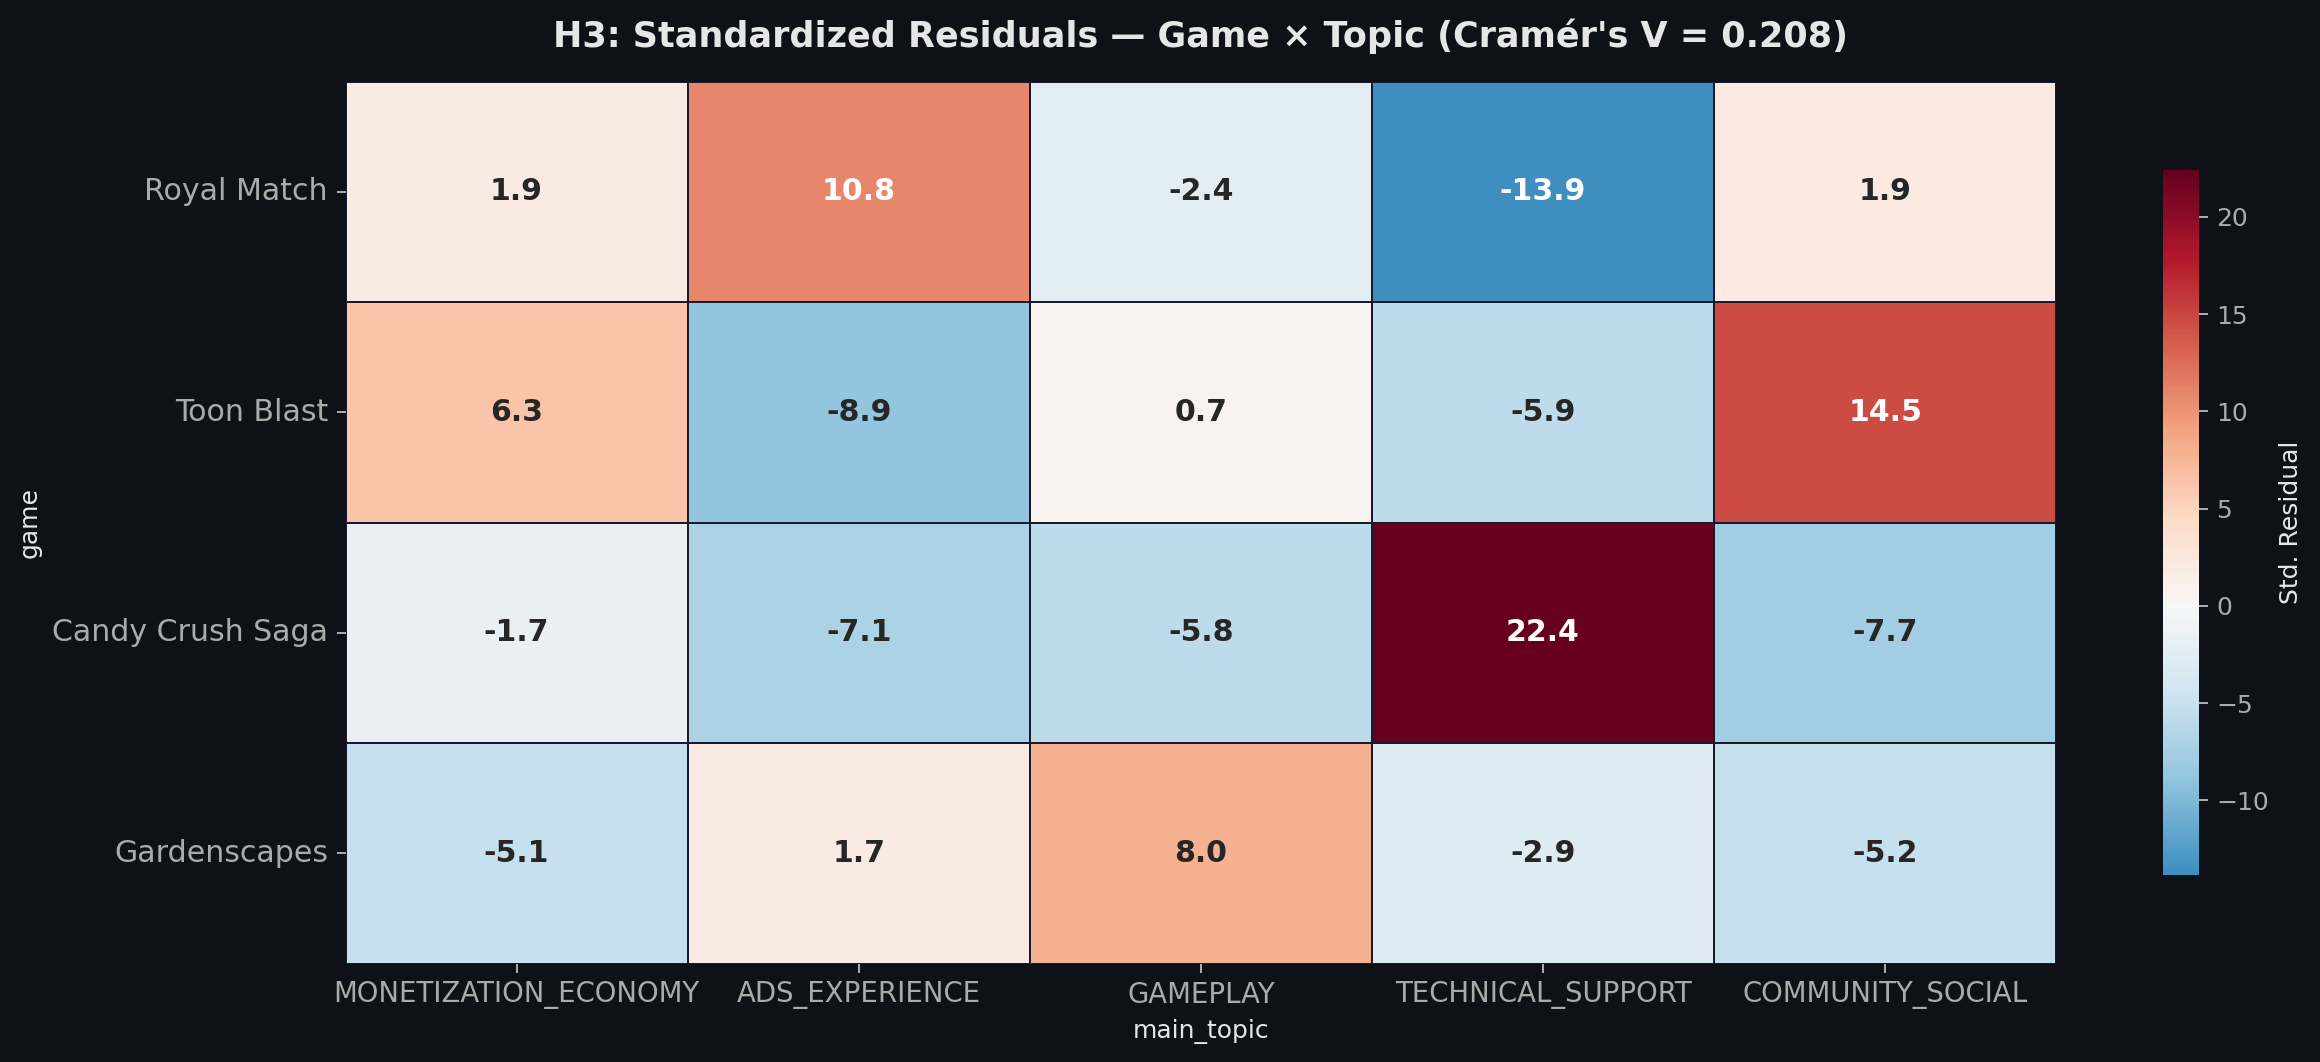

In [20]:
# =============================================================================
# H3 — Is topic distribution different across games?
# Chi-square independence test
# =============================================================================
section("H3 — Topic Distribution Across Games")

ct_h3 = pd.crosstab(df_seg_clean["game"], df_seg_clean["main_topic"])
chi2, p, dof, expected = stats.chi2_contingency(ct_h3)

# Cramér's V
k = min(ct_h3.shape)
cramers_v = np.sqrt(chi2 / (ct_h3.values.sum() * (k - 1)))

print(f"  H₀: Topic distribution is independent of game")
print(f"  H₁: Topic distribution differs across games")
print(f"  χ²         : {chi2:.2f}")
print(f"  dof        : {dof}")
print(f"  p-value    : {p:.2e}  {'→ REJECT H₀' if p < ALPHA else '→ FAIL TO REJECT H₀'}")
print(f"  Cramér's V : {cramers_v:.3f}")

# Standardized residuals (observed - expected) / sqrt(expected)
std_resid = (ct_h3.values - expected) / np.sqrt(expected)
df_resid = pd.DataFrame(std_resid, index=ct_h3.index, columns=ct_h3.columns)

section("H3 — Standardized Residuals (|z| > 2 = notable)")
print(df_resid.round(2).to_string())

# Heatmap of residuals
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df_resid.reindex(columns=TOPIC_ORDER_CLEAN).reindex(GAME_ORDER),
            annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=0.8, linecolor="#1a1a2e",
            annot_kws={"fontweight": "bold", "fontsize": 12},
            cbar_kws={"label": "Std. Residual", "shrink": 0.8}, ax=ax)
ax.set_title(f"H3: Standardized Residuals — Game × Topic (Cramér's V = {cramers_v:.3f})",
             fontsize=14, fontweight="bold", pad=14)
ax.tick_params(axis="y", labelsize=12, rotation=0)
ax.tick_params(axis="x", labelsize=11)
plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# H4 — Does hidden dissatisfaction concentrate in specific topics?
# Chi-square: hidden_dissatisfied (yes/no) × main_topic
# =============================================================================
section("H4 — Hidden Dissatisfaction × Topic Concentration")

# Flag segments: is this segment in a hidden dissatisfied review (4-5★ + neg)?
df_seg_h4 = df_segments[~df_segments.main_topic.isin(["UNASSIGNED", "OTHER"])].copy()
df_seg_h4["is_hidden_dissatisfied"] = (
    (df_seg_h4.rating >= 4) & (df_seg_h4.review_sentiment == "negative")
)

ct_h4 = pd.crosstab(df_seg_h4["main_topic"], df_seg_h4["is_hidden_dissatisfied"])
chi2, p, dof, expected = stats.chi2_contingency(ct_h4)

k = min(ct_h4.shape)
cramers_v = np.sqrt(chi2 / (ct_h4.values.sum() * (k - 1)))

print(f"  H₀: Hidden dissatisfaction is distributed uniformly across topics")
print(f"  H₁: Hidden dissatisfaction concentrates in specific topics")
print(f"  χ²         : {chi2:.2f}")
print(f"  dof        : {dof}")
print(f"  p-value    : {p:.2e}  {'→ REJECT H₀' if p < ALPHA else '→ FAIL TO REJECT H₀'}")
print(f"  Cramér's V : {cramers_v:.3f}")

# Standardized residuals
std_resid_h4 = (ct_h4.values - expected) / np.sqrt(expected)
df_resid_h4 = pd.DataFrame(std_resid_h4, index=ct_h4.index, columns=["Not HD", "Hidden Dissatisfied"])

section("H4 — Standardized Residuals")
print(df_resid_h4.round(2).to_string())
print("\n  Positive residual in 'Hidden Dissatisfied' column = over-represented in HD group")


H4 — Hidden Dissatisfaction × Topic Concentration
  H₀: Hidden dissatisfaction is distributed uniformly across topics
  H₁: Hidden dissatisfaction concentrates in specific topics
  χ²         : 46.28
  dof        : 4
  p-value    : 2.15e-09  → REJECT H₀
  Cramér's V : 0.064

H4 — Standardized Residuals
                      Not HD  Hidden Dissatisfied
main_topic                                       
ADS_EXPERIENCE          0.97                -3.01
COMMUNITY_SOCIAL       -0.91                 2.83
GAMEPLAY               -0.74                 2.31
MONETIZATION_ECONOMY    0.85                -2.65
TECHNICAL_SUPPORT      -1.14                 3.54

  Positive residual in 'Hidden Dissatisfied' column = over-represented in HD group


In [22]:
# =============================================================================
# H5 — Is sentiment distribution different across countries?
# Chi-square independence test
# =============================================================================
section("H5 — Sentiment Distribution Across Countries")

df_h5 = df_reviews[df_reviews.country.isin(COUNTRY_ORDER)].copy()
ct_h5 = pd.crosstab(df_h5["country"], df_h5["ml_sentiment"])
chi2_h5, p_h5, dof, expected = stats.chi2_contingency(ct_h5)

k = min(ct_h5.shape)
cramers_v_h5 = np.sqrt(chi2_h5 / (ct_h5.values.sum() * (k - 1)))

print(f"  H₀: Sentiment distribution is independent of country")
print(f"  H₁: Sentiment distribution differs across countries")
print(f"  χ²         : {chi2_h5:.2f}")
print(f"  dof        : {dof}")
print(f"  p-value    : {p_h5:.2e}  {'→ REJECT H₀' if p_h5 < ALPHA else '→ FAIL TO REJECT H₀'}")
print(f"  Cramér's V : {cramers_v_h5:.3f}")

# Standardized residuals
std_resid_h5 = (ct_h5.values - expected) / np.sqrt(expected)
df_resid_h5 = pd.DataFrame(std_resid_h5, index=ct_h5.index, columns=ct_h5.columns)

section("H5 — Standardized Residuals")
print(df_resid_h5.reindex(COUNTRY_ORDER).round(2).to_string())


H5 — Sentiment Distribution Across Countries
  H₀: Sentiment distribution is independent of country
  H₁: Sentiment distribution differs across countries
  χ²         : 153.80
  dof        : 4
  p-value    : 3.12e-32  → REJECT H₀
  Cramér's V : 0.146

H5 — Standardized Residuals
ml_sentiment    negative  positive
country                           
United States      -3.25      5.16
United Kingdom     -3.07      4.86
Turkey              3.93     -6.22
Germany             2.87     -4.55
Canada              0.41     -0.64


In [23]:
# =============================================================================
# H6 — Is Royal Match's hidden dissatisfaction rate different from competitors?
# Chi-square: game (RM vs competitors) × hidden_dissatisfied (yes/no)
# =============================================================================
section("H6 — Royal Match vs Competitors: Hidden Dissatisfaction Rate")

df_high_h6 = df_reviews[df_reviews.rating >= 4].copy()
df_high_h6["hidden_dissatisfied"] = df_high_h6["ml_sentiment"] == "negative"
df_high_h6["is_rm"] = df_high_h6["game"] == "Royal Match"

# Per-game rates for context
for game in GAME_ORDER:
    sub = df_high_h6[df_high_h6.game == game]
    hd = sub.hidden_dissatisfied.sum()
    total = len(sub)
    print(f"  {game:<20}: {hd}/{total} = {hd/total*100:.1f}%")

# Test: RM vs all competitors pooled
ct_h6 = pd.crosstab(df_high_h6["is_rm"], df_high_h6["hidden_dissatisfied"])
chi2_h6, p_h6, dof_h6, expected_h6 = stats.chi2_contingency(ct_h6)

cramers_v_h6 = np.sqrt(chi2_h6 / (ct_h6.values.sum() * (min(ct_h6.shape) - 1)))

# Also run proportion z-test for directional insight
from statsmodels.stats.proportion import proportions_ztest

rm_high = df_high_h6[df_high_h6.is_rm]
comp_high = df_high_h6[~df_high_h6.is_rm]

count = np.array([rm_high.hidden_dissatisfied.sum(), comp_high.hidden_dissatisfied.sum()])
nobs = np.array([len(rm_high), len(comp_high)])

z_stat, p_z = proportions_ztest(count, nobs, alternative="two-sided")

print(f"\n  Royal Match HD rate : {count[0]/nobs[0]*100:.1f}% ({count[0]}/{nobs[0]})")
print(f"  Competitors HD rate: {count[1]/nobs[1]*100:.1f}% ({count[1]}/{nobs[1]})")
print(f"  Difference         : {count[0]/nobs[0]*100 - count[1]/nobs[1]*100:+.1f} pp")

print(f"\n  Chi-square test:")
print(f"  H₀: RM hidden dissatisfaction rate = Competitor rate")
print(f"  H₁: RM hidden dissatisfaction rate ≠ Competitor rate")
print(f"  χ²         : {chi2_h6:.2f}")
print(f"  p-value    : {p_h6:.4f}  {'→ REJECT H₀' if p_h6 < ALPHA else '→ FAIL TO REJECT H₀'}")
print(f"  Cramér's V : {cramers_v_h6:.3f}")

print(f"\n  Proportion z-test:")
print(f"  z-statistic: {z_stat:.3f}")
print(f"  p-value    : {p_z:.4f}  {'→ REJECT H₀' if p_z < ALPHA else '→ FAIL TO REJECT H₀'}")


H6 — Royal Match vs Competitors: Hidden Dissatisfaction Rate
  Royal Match         : 207/789 = 26.2%
  Toon Blast          : 113/510 = 22.2%
  Candy Crush Saga    : 170/574 = 29.6%
  Gardenscapes        : 161/693 = 23.2%

  Royal Match HD rate : 26.2% (207/789)
  Competitors HD rate: 25.0% (444/1777)
  Difference         : +1.2 pp

  Chi-square test:
  H₀: RM hidden dissatisfaction rate = Competitor rate
  H₁: RM hidden dissatisfaction rate ≠ Competitor rate
  χ²         : 0.39
  p-value    : 0.5338  → FAIL TO REJECT H₀
  Cramér's V : 0.012

  Proportion z-test:
  z-statistic: 0.671
  p-value    : 0.5020  → FAIL TO REJECT H₀


In [24]:
# =============================================================================
# HYPOTHESIS TESTING — SUMMARY TABLE
# =============================================================================
section("HYPOTHESIS TESTING — SUMMARY")

h1a_p = result_neg["p"] if result_neg else "—"
h1a_r = result_neg["r"] if result_neg else "—"
h1b_p = result_pos["p"] if result_pos else "—"
h1b_r = result_pos["r"] if result_pos else "—"

summary_data = {
    "Test":       ["H1a", "H1b", "H2", "H3", "H4", "H5", "H6"],
    "Question":   [
        "Negative update sentiment drop (v32672)",
        "Positive update sentiment lift (v32131)",
        "Topic effect on rating",
        "Topic distribution × game",
        "Hidden dissatisfaction × topic",
        "Sentiment × country",
        "RM vs competitors HD rate",
    ],
    "Method":     [
        "Mann-Whitney U", "Mann-Whitney U", "Kruskal-Wallis",
        "Chi-square", "Chi-square", "Chi-square", "Chi-square + z-test",
    ],
    "p-value":    [
        f"{h1a_p:.4f}" if isinstance(h1a_p, float) else h1a_p,
        f"{h1b_p:.4f}" if isinstance(h1b_p, float) else h1b_p,
        "8.18e-53", "2.02e-306",
        "2.15e-09", f"{p_h5:.2e}", f"{p_h6:.4f}",
    ],
    "Effect Size": [
        f"r={h1a_r:.3f}" if isinstance(h1a_r, float) else h1a_r,
        f"r={h1b_r:.3f}" if isinstance(h1b_r, float) else h1b_r,
        "η²=0.022", "V=0.208",
        "V=0.064", f"V={cramers_v_h5:.3f}", f"V={cramers_v_h6:.3f}",
    ],
    "Decision":   [
        "FAIL TO REJECT" if isinstance(h1a_p, float) and h1a_p >= ALPHA else "REJECT",
        "FAIL TO REJECT" if isinstance(h1b_p, float) and h1b_p >= ALPHA else "REJECT",
        "REJECT ***", "REJECT ***", "REJECT ***", "REJECT ***",
        "REJECT ***" if p_h6 < ALPHA else "FAIL TO REJECT",
    ],
}
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


HYPOTHESIS TESTING — SUMMARY
Test                                Question              Method   p-value Effect Size       Decision
 H1a Negative update sentiment drop (v32672)      Mann-Whitney U    0.5211     r=0.004 FAIL TO REJECT
 H1b Positive update sentiment lift (v32131)      Mann-Whitney U    0.3092     r=0.039 FAIL TO REJECT
  H2                  Topic effect on rating      Kruskal-Wallis  8.18e-53    η²=0.022     REJECT ***
  H3               Topic distribution × game          Chi-square 2.02e-306     V=0.208     REJECT ***
  H4          Hidden dissatisfaction × topic          Chi-square  2.15e-09     V=0.064     REJECT ***
  H5                     Sentiment × country          Chi-square  3.12e-32     V=0.146     REJECT ***
  H6               RM vs competitors HD rate Chi-square + z-test    0.5338     V=0.012 FAIL TO REJECT


### Step 05 — Summary

**4 out of 7 hypotheses rejected — structural patterns validated, event-level effects not confirmed.**

**H1a & H1b (FAIL TO REJECT):** Neither the negative update candidate (v32672, p=0.52) nor the positive one (v32131, p=0.31) produced statistically significant sentiment shifts. Pre/post neg rates barely changed (79.5→79.1% and 69.3→65.4% respectively). Three factors likely explain this: (a) small post-window samples (43 and 52 reviews) limit statistical power, (b) the App Store version field reflects store-level versions, not user-installed versions — a known data limitation, and (c) update impacts may manifest in rating behavior rather than sentiment content. Version-level sentiment analysis requires higher-resolution data than App Store RSS provides.

**H2 (REJECT, p≈0, η²=0.022):** Topic significantly affects rating but with small effect size. MONETIZATION and TECHNICAL_SUPPORT segments carry median 1★ ratings; GAMEPLAY and COMMUNITY_SOCIAL carry 2★. Dunn post-hoc confirms 8 of 10 topic pairs differ significantly. The practical reading: monetization and technical complaints pull ratings to the floor, while gameplay frustration sits one tier higher — reinforcing the "silent dissatisfaction" pattern where gameplay issues don't fully surface in ratings.

**H3 (REJECT, p≈0, V=0.208):** The strongest result with medium effect size. Each game has a statistically distinct topic fingerprint. Key signatures: Candy Crush Saga massively over-indexes on TECHNICAL_SUPPORT (+22.4 std. residual), Royal Match on ADS_EXPERIENCE (+10.8), Toon Blast on COMMUNITY_SOCIAL (+14.5), Gardenscapes on GAMEPLAY (+8.0). Competitive benchmarking must be topic-aware — aggregate sentiment comparison misses these structural differences.

**H4 (REJECT, p=2.15e-9, V=0.064):** Hidden dissatisfaction concentrates in specific topics. TECHNICAL_SUPPORT (+3.54), COMMUNITY_SOCIAL (+2.83), and GAMEPLAY (+2.31) are over-represented in the hidden dissatisfied group, while MONETIZATION (-2.65) and ADS (-3.01) are under-represented. This statistically confirms Step 4's core finding: monetization and ads complaints surface openly in ratings, but gameplay and technical issues create silent frustration detectable only through text analysis.

**H5 (REJECT, p=3.12e-32, V=0.146):** Sentiment distribution differs significantly across countries. Turkey (+3.93) and Germany (+2.87) are systematically more negative; US (-3.25) and UK (-3.07) more positive; Canada neutral. This validates market-specific product strategies — a single global sentiment benchmark masks meaningful structural differences.

**H6 (FAIL TO REJECT, p=0.53, V=0.012):** Royal Match's hidden dissatisfaction rate (26.2%) is not statistically different from the competitor average (25.0%). The +1.2pp gap is negligible. This is actually a useful null result: hidden dissatisfaction is a **category-level phenomenon**, not an RM-specific weakness. All puzzle games in this dataset share a similar rate of users who give high ratings despite negative sentiment — the problem is structural to the genre, not to any single product.

## Step 06 — Executive Summary

This notebook synthesized outputs from four ML/NLP pipelines — EDA, BERTopic topic modeling, review-level sentiment classification, and aspect-based sentiment analysis (ABSA) — into a unified analytical layer. The analysis covered 7,236 App Store reviews (14,107 segments) across Royal Match and three competitors (Candy Crush Saga, Toon Blast, Gardenscapes) in 5 markets (US, UK, TR, DE, CA) over a 12-month period (Jan 2025 – Jan 2026).

---

### Key Findings

**1. Star ratings systematically overestimate satisfaction.**
50.7% of 4★ and 19.1% of 5★ reviews carry negative sentiment. The reverse is negligible (1.4% of 1-2★ are positive). This asymmetry means any product intelligence system relying solely on star ratings will significantly undercount dissatisfied users — particularly in Turkey, where 48.4% of high-rating reviews are negative.

**2. MONETIZATION is the #1 product pain point by both intensity and reach.**
92.7% negative rate with 36.0% impact (2,122 reviews affected). At subtopic level, MONETIZATION_P2W_REFUNDS alone accounts for 28.2% of all negative review volume. TECHNICAL_SUPPORT is more intense (93.2% neg rate) but affects fewer reviews (18.6% impact).

**3. Hidden dissatisfaction reveals "silent" product risks invisible to ratings.**
ABSA adds 13.7% more signal than review-level sentiment. Inside positive reviews, the dominant complaint topic shifts from MONETIZATION to **GAMEPLAY** (38.2%) — specifically DIFFICULTY_BALANCE. Users who like the game overall still complain about difficulty tuning and bugs, but these frustrations don't surface in star ratings. Statistical testing (H4) confirms this concentration is significant (p=2.15e-9).

**4. Each game has a distinct competitive "pain fingerprint".**
Topic profiles differ significantly across games (H3: Cramér's V=0.208). Royal Match's defining issue is ADS_EXPERIENCE (+10.8 std. residual), Candy Crush Saga's is TECHNICAL_SUPPORT (+22.4), Toon Blast's is COMMUNITY_SOCIAL (+14.5), Gardenscapes' is GAMEPLAY (+8.0). Aggregate sentiment benchmarking misses these structural differences.

**5. Market-level sentiment varies significantly.**
Turkey and Germany produce systematically more negative sentiment than US and UK (H5: p=3.12e-32). This is not noise — it reflects either cultural expression patterns or genuine market-specific product experiences. Localized response strategies are warranted.

**6. Version-level sentiment impact could not be confirmed.**
Neither the strongest negative (v32672) nor positive (v32131) update candidate showed a statistically significant sentiment shift (H1a: p=0.52, H1b: p=0.31). This is likely a data resolution limitation — App Store version fields reflect store-level versions, not user-installed versions.

**7. Hidden dissatisfaction is a category-level phenomenon.**
Royal Match's hidden dissatisfaction rate (26.2%) is not statistically different from the competitor average (25.0%, H6: p=0.53). This suggests the pattern is structural to the mobile puzzle genre, not specific to any single product.

---

### Limitations

- **App Store only.** Google Play data was not included. Cross-store patterns may differ.
- **RSS feed sampling bias.** App Store RSS prioritizes recent and extreme reviews — the dataset is not a random sample of all user sentiment.
- **Version field is approximate.** App Store versions reflect store state at review time, not the user's installed version, limiting update impact analysis.
- **Segment-level ABSA covers 81.6% of reviews.** 1,335 reviews (18.4%) were too short for segmentation and are excluded from topic-level analyses.
- **BERTopic coverage.** UNASSIGNED segments (2,349) represent topics the model couldn't classify — a non-trivial blind spot.
- **Temporal scope.** 12 months of data. Seasonal effects and long-term trends may require a longer observation window.

---

### Pipeline Summary

| Step | Focus | Key Metric |
|------|-------|------------|
| 01 | Data integration | 7,236 reviews → 14,107 segments, 86.3% segment-review agreement |
| 02 | Sentiment × Rating | 50.7% of 4★ reviews are negative; TR hidden dissatisfaction at 48.4% |
| 03 | Topic × Sentiment | MONETIZATION: 36.0% impact; each game has distinct topic fingerprint |
| 04 | ABSA value-add | 13.7% disagreement; hidden negativity led by GAMEPLAY not MONETIZATION |
| 05 | Hypothesis testing | 4/7 rejected; structural patterns confirmed, event-level effects not |